# Step 17 — Feature-Group Ablation by Demand Type

## Purpose

This notebook evaluates how the usefulness of the five feature groups differs across smooth, erratic, intermittent and lumpy demand.

The five feature groups are:

1. Lag features
2. Rolling features
3. Calendar features
4. Event and SNAP features
5. Price features

A leave-one-group-out ablation design is used. Each ablation model removes one feature group while retaining the remaining features.

The ablation models use the same fold-specific and demand-type-specific boosting rounds selected for the complete XGBoost models in Step 16. Hyperparameters are not retuned after feature removal. This keeps the comparison focused on the effect of removing each feature group.

The primary measure is:

**ΔWRMSSE = ablated-model WRMSSE − full-model WRMSSE**

A positive ΔWRMSSE means that performance deteriorated after the feature group was removed, which provides evidence that the group was useful. A negative ΔWRMSSE means that the ablated model performed better than the complete model.

MAE and RMSE are reported as secondary measures.

All results are reported separately by demand type. Results are descriptive and do not establish causal feature effects.

In [1]:
# Cell 1: Environment and project paths

from pathlib import Path

import gc
import json
import os
import time
import warnings

import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

warnings.filterwarnings("ignore")

SEED = 42

np.random.seed(SEED)

CURRENT_DIRECTORY = Path.cwd().resolve()

if CURRENT_DIRECTORY.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_RESULTS_DIR = OUTPUT_DIR / "model_results"

STEP16_TABLE_DIR = TABLE_DIR / "step16"

STEP17_TABLE_DIR = TABLE_DIR / "step17"
STEP17_FIGURE_DIR = FIGURE_DIR / "step17"
STEP17_RESULT_DIR = MODEL_RESULTS_DIR / "step17"

STEP17_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

STEP17_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

STEP17_RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODELLING_DATA_FILE = (
    PROCESSED_DATA_DIR
    / "modelling_dataset.parquet"
)

STEP16_RESULTS_FILE = (
    STEP16_TABLE_DIR
    / "step16_xgb_fold_results.csv"
)

STEP16_PREDICTIONS_FILE = (
    MODEL_RESULTS_DIR
    / "step16_xgb_predictions.parquet"
)

STEP16_CONFIGURATION_FILE = (
    STEP16_TABLE_DIR
    / "step16_configuration.json"
)

N_THREADS = max(
    1,
    min(
        8,
        os.cpu_count() or 1,
    ),
)

print("Step 17 environment")
print("-" * 70)
print(f"Project root: {PROJECT_ROOT}")
print(f"XGBoost version: {xgb.__version__}")
print(f"Random seed: {SEED}")
print(f"CPU threads: {N_THREADS}")
print(f"Step 17 table directory: {STEP17_TABLE_DIR}")
print(f"Step 17 figure directory: {STEP17_FIGURE_DIR}")

assert PROJECT_ROOT.exists()
assert MODELLING_DATA_FILE.exists()
assert STEP16_RESULTS_FILE.exists()
assert STEP16_PREDICTIONS_FILE.exists()
assert STEP16_CONFIGURATION_FILE.exists()

print("\nEnvironment and path checks passed.")

Step 17 environment
----------------------------------------------------------------------
Project root: C:\Users\gamec\Documents\MSc_Dissertation_M5
XGBoost version: 3.3.0
Random seed: 42
CPU threads: 8
Step 17 table directory: C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step17
Step 17 figure directory: C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step17

Environment and path checks passed.


In [2]:
# Cell 2: Load Step 16 inputs and validated results

load_start = time.perf_counter()

model_df = pd.read_parquet(
    MODELLING_DATA_FILE
)

step16_fold_results = pd.read_csv(
    STEP16_RESULTS_FILE,
    parse_dates=[
        "train_end",
        "test_start",
        "test_end",
    ],
)

step16_full_predictions = pd.read_parquet(
    STEP16_PREDICTIONS_FILE
)

with open(
    STEP16_CONFIGURATION_FILE,
    "r",
    encoding="utf-8",
) as configuration_file:
    step16_configuration = json.load(
        configuration_file
    )

load_seconds = (
    time.perf_counter()
    - load_start
)

print("Loaded Step 17 inputs")
print("-" * 70)
print(
    f"Modelling rows: "
    f"{len(model_df):,}"
)
print(
    f"Modelling columns: "
    f"{model_df.shape[1]}"
)
print(
    f"Step 16 result rows: "
    f"{len(step16_fold_results):,}"
)
print(
    f"Step 16 prediction rows: "
    f"{len(step16_full_predictions):,}"
)
print(
    f"Unique Step 16 prediction series: "
    f"{step16_full_predictions['id'].nunique():,}"
)
print(
    f"Load time: "
    f"{load_seconds:.2f} seconds"
)

input_checks = {
    "1,552,800 modelling rows": (
        len(model_df) == 1_552_800
    ),
    "20 Step 16 result rows": (
        len(step16_fold_results) == 20
    ),
    "112,000 Step 16 predictions": (
        len(step16_full_predictions)
        == 112_000
    ),
    "5 folds represented": (
        step16_fold_results[
            "fold"
        ].nunique() == 5
    ),
    "4 demand types represented": (
        step16_fold_results[
            "demand_type"
        ].nunique() == 4
    ),
    "One result per fold and demand type": (
        step16_fold_results
        .duplicated(
            subset=[
                "fold",
                "demand_type",
            ]
        )
        .sum() == 0
    ),
    "No missing selected rounds": (
        step16_fold_results[
            "selected_rounds"
        ].isna().sum() == 0
    ),
    "No missing full-model forecasts": (
        step16_full_predictions[
            "xgb_forecast"
        ].isna().sum() == 0
    ),
    "No negative full-model forecasts": (
        (
            step16_full_predictions[
                "xgb_forecast"
            ] < 0
        ).sum() == 0
    ),
}

input_check_table = pd.DataFrame(
    {
        "check": input_checks.keys(),
        "passed": input_checks.values(),
    }
)

display(input_check_table)

failed_input_checks = [
    check
    for check, passed
    in input_checks.items()
    if not passed
]

if failed_input_checks:
    raise AssertionError(
        "Step 17 input audit failed:\n- "
        + "\n- ".join(
            failed_input_checks
        )
    )

print("\nStep 17 input audit passed.")

Loaded Step 17 inputs
----------------------------------------------------------------------
Modelling rows: 1,552,800
Modelling columns: 39
Step 16 result rows: 20
Step 16 prediction rows: 112,000
Unique Step 16 prediction series: 800
Load time: 0.44 seconds


,check,passed
0,"1,552,800 modelling rows",True
1,20 Step 16 result rows,True
2,"112,000 Step 16 predictions",True
3,5 folds represented,True
4,4 demand types represented,True
5,One result per fold and demand type,True
6,No missing selected rounds,True
7,No missing full-model forecasts,True
8,No negative full-model forecasts,True



Step 17 input audit passed.


In [3]:
# Cell 3: Define and audit the five feature groups

DEMAND_TYPES = [
    "smooth",
    "erratic",
    "intermittent",
    "lumpy",
]

LAG_FEATURES = [
    "lag_7",
    "lag_14",
    "lag_28",
    "lag_56",
]

ROLLING_FEATURES = [
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_28",
    "rolling_std_28",
]

CALENDAR_FEATURES = [
    "is_weekend",
    "weekday",
    "month",
    "year",
]

EVENT_SNAP_FEATURES = [
    "event_flag",
    "event_type_encoded",
    "snap_flag",
]

PRICE_FEATURES = [
    "sell_price",
    "price_change",
    "price_vs_28d_avg",
]

FEATURE_GROUPS = {
    "lag": LAG_FEATURES,
    "rolling": ROLLING_FEATURES,
    "calendar": CALENDAR_FEATURES,
    "event_snap": EVENT_SNAP_FEATURES,
    "price": PRICE_FEATURES,
}

FULL_MODEL_FEATURES = [
    feature
    for feature_group in FEATURE_GROUPS.values()
    for feature in feature_group
]

ABLATION_FEATURE_SETS = {
    f"without_{group_name}": [
        feature
        for feature in FULL_MODEL_FEATURES
        if feature not in removed_features
    ]
    for group_name, removed_features
    in FEATURE_GROUPS.items()
}

feature_group_summary = pd.DataFrame(
    [
        {
            "feature_group": group_name,
            "features_removed": ", ".join(
                features
            ),
            "removed_feature_count": len(
                features
            ),
            "remaining_feature_count": len(
                ABLATION_FEATURE_SETS[
                    f"without_{group_name}"
                ]
            ),
        }
        for group_name, features
        in FEATURE_GROUPS.items()
    ]
)

display(feature_group_summary)

all_group_features = [
    feature
    for features in FEATURE_GROUPS.values()
    for feature in features
]

duplicate_features = sorted(
    {
        feature
        for feature in all_group_features
        if all_group_features.count(feature) > 1
    }
)

missing_model_features = sorted(
    set(FULL_MODEL_FEATURES)
    .difference(model_df.columns)
)

non_numeric_features = [
    feature
    for feature in FULL_MODEL_FEATURES
    if not pd.api.types.is_numeric_dtype(
        model_df[feature]
    )
]

expected_ablation_sizes = {
    "without_lag": 14,
    "without_rolling": 14,
    "without_calendar": 14,
    "without_event_snap": 15,
    "without_price": 15,
}

actual_ablation_sizes = {
    ablation_name: len(features)
    for ablation_name, features
    in ABLATION_FEATURE_SETS.items()
}

feature_checks = {
    "18 complete-model features": (
        len(FULL_MODEL_FEATURES) == 18
    ),
    "5 feature groups": (
        len(FEATURE_GROUPS) == 5
    ),
    "No feature appears in two groups": (
        len(duplicate_features) == 0
    ),
    "All features exist in modelling data": (
        len(missing_model_features) == 0
    ),
    "All model features are numeric": (
        len(non_numeric_features) == 0
    ),
    "Ablation feature counts correct": (
        actual_ablation_sizes
        == expected_ablation_sizes
    ),
}

feature_check_table = pd.DataFrame(
    {
        "check": feature_checks.keys(),
        "passed": feature_checks.values(),
    }
)

display(feature_check_table)

print(f"Duplicate features: {duplicate_features}")
print(
    f"Missing model features: "
    f"{missing_model_features}"
)
print(
    f"Non-numeric model features: "
    f"{non_numeric_features}"
)

failed_feature_checks = [
    check
    for check, passed
    in feature_checks.items()
    if not passed
]

if failed_feature_checks:
    raise AssertionError(
        "Feature-group audit failed:\n- "
        + "\n- ".join(
            failed_feature_checks
        )
    )

print("\nFeature-group configuration passed.")

,feature_group,features_removed,removed_feature_count,remaining_feature_count
0,lag,"lag_7, lag_14, lag_28, lag_56",4,14
1,rolling,"rolling_mean_7, rolling_std_7, rolling_mean_28...",4,14
2,calendar,"is_weekend, weekday, month, year",4,14
3,event_snap,"event_flag, event_type_encoded, snap_flag",3,15
4,price,"sell_price, price_change, price_vs_28d_avg",3,15


,check,passed
0,18 complete-model features,True
1,5 feature groups,True
2,No feature appears in two groups,True
3,All features exist in modelling data,True
4,All model features are numeric,True
5,Ablation feature counts correct,True


Duplicate features: []
Missing model features: []
Non-numeric model features: []

Feature-group configuration passed.


In [4]:
# Cell 4: Build and audit the complete ablation plan

ablation_plan_records = []

for _, result_row in (
    step16_fold_results.iterrows()
):
    fold_number = int(
        result_row["fold"]
    )

    demand_type = str(
        result_row["demand_type"]
    )

    selected_rounds = int(
        result_row["selected_rounds"]
    )

    for (
        feature_group,
        removed_features,
    ) in FEATURE_GROUPS.items():

        ablation_name = (
            f"without_{feature_group}"
        )

        retained_features = (
            ABLATION_FEATURE_SETS[
                ablation_name
            ]
        )

        ablation_plan_records.append(
            {
                "fold": fold_number,
                "demand_type": demand_type,
                "ablation_name": (
                    ablation_name
                ),
                "removed_feature_group": (
                    feature_group
                ),
                "removed_features": ", ".join(
                    removed_features
                ),
                "removed_feature_count": len(
                    removed_features
                ),
                "retained_feature_count": len(
                    retained_features
                ),
                "selected_rounds": (
                    selected_rounds
                ),
                "train_end": pd.Timestamp(
                    result_row["train_end"]
                ),
                "test_start": pd.Timestamp(
                    result_row["test_start"]
                ),
                "test_end": pd.Timestamp(
                    result_row["test_end"]
                ),
                "full_xgb_wrmsse": float(
                    result_row["xgb_wrmsse"]
                ),
                "full_xgb_mae": float(
                    result_row["xgb_mae"]
                ),
                "full_xgb_rmse": float(
                    result_row["xgb_rmse"]
                ),
            }
        )

ablation_plan = (
    pd.DataFrame(
        ablation_plan_records
    )
    .sort_values(
        [
            "fold",
            "demand_type",
            "removed_feature_group",
        ]
    )
    .reset_index(drop=True)
)

display(
    ablation_plan.head(15)
)

ablation_plan_checks = {
    "100 planned ablation models": (
        len(ablation_plan) == 100
    ),
    "5 folds represented": (
        ablation_plan[
            "fold"
        ].nunique() == 5
    ),
    "4 demand types represented": (
        ablation_plan[
            "demand_type"
        ].nunique() == 4
    ),
    "5 ablations per fold and type": (
        ablation_plan
        .groupby(
            [
                "fold",
                "demand_type",
            ],
            observed=True,
        )["ablation_name"]
        .nunique()
        .eq(5)
        .all()
    ),
    "No duplicate experiment": (
        ablation_plan
        .duplicated(
            subset=[
                "fold",
                "demand_type",
                "ablation_name",
            ]
        )
        .sum() == 0
    ),
    "All selected rounds positive": (
        ablation_plan[
            "selected_rounds"
        ] > 0
    ).all(),
    "All training periods end before tests": (
        ablation_plan[
            "train_end"
        ] < ablation_plan[
            "test_start"
        ]
    ).all(),
    "Every test window is 28 days": (
        (
            ablation_plan[
                "test_end"
            ]
            - ablation_plan[
                "test_start"
            ]
        ).dt.days.add(1).eq(28).all()
    ),
}

ablation_plan_check_table = pd.DataFrame(
    {
        "check": (
            ablation_plan_checks.keys()
        ),
        "passed": (
            ablation_plan_checks.values()
        ),
    }
)

display(ablation_plan_check_table)

ablation_count_pivot = (
    ablation_plan
    .pivot_table(
        index="fold",
        columns="demand_type",
        values="ablation_name",
        aggfunc="nunique",
    )
    .reindex(
        columns=DEMAND_TYPES
    )
)

print("Number of ablation experiments per fold and demand type")
display(ablation_count_pivot)

failed_plan_checks = [
    check
    for check, passed
    in ablation_plan_checks.items()
    if not passed
]

if failed_plan_checks:
    raise AssertionError(
        "Ablation-plan audit failed:\n- "
        + "\n- ".join(
            failed_plan_checks
        )
    )

ablation_plan.to_csv(
    STEP17_TABLE_DIR
    / "step17_ablation_plan.csv",
    index=False,
)

print("\nStep 17 ablation plan passed.")
print(
    f"Planned models: "
    f"{len(ablation_plan)}"
)
print(
    "Saved:"
)
print(
    STEP17_TABLE_DIR
    / "step17_ablation_plan.csv"
)

,fold,demand_type,ablation_name,removed_feature_group,removed_features,removed_feature_count,retained_feature_count,selected_rounds,train_end,test_start,test_end,full_xgb_wrmsse,full_xgb_mae,full_xgb_rmse
0,1,erratic,without_calendar,calendar,"is_weekend, weekday, month, year",4,14,970,2016-01-03,2016-01-04,2016-01-31,1.053686,3.639830,6.276018
1,1,erratic,without_event_snap,event_snap,"event_flag, event_type_encoded, snap_flag",3,15,970,2016-01-03,2016-01-04,2016-01-31,1.053686,3.639830,6.276018
2,1,erratic,without_lag,lag,"lag_7, lag_14, lag_28, lag_56",4,14,970,2016-01-03,2016-01-04,2016-01-31,1.053686,3.639830,6.276018
3,1,erratic,without_price,price,"sell_price, price_change, price_vs_28d_avg",3,15,970,2016-01-03,2016-01-04,2016-01-31,1.053686,3.639830,6.276018
4,1,erratic,without_rolling,rolling,"rolling_mean_7, rolling_std_7, rolling_mean_28...",4,14,970,2016-01-03,2016-01-04,2016-01-31,1.053686,3.639830,6.276018
5,1,intermittent,without_calendar,calendar,"is_weekend, weekday, month, year",4,14,1250,2016-01-03,2016-01-04,2016-01-31,1.351116,0.573124,1.151051
6,1,intermittent,without_event_snap,event_snap,"event_flag, event_type_encoded, snap_flag",3,15,1250,2016-01-03,2016-01-04,2016-01-31,1.351116,0.573124,1.151051
7,1,intermittent,without_lag,lag,"lag_7, lag_14, lag_28, lag_56",4,14,1250,2016-01-03,2016-01-04,2016-01-31,1.351116,0.573124,1.151051
8,1,intermittent,without_price,price,"sell_price, price_change, price_vs_28d_avg",3,15,1250,2016-01-03,2016-01-04,2016-01-31,1.351116,0.573124,1.151051
9,1,intermittent,without_rolling,rolling,"rolling_mean_7, rolling_std_7, rolling_mean_28...",4,14,1250,2016-01-03,2016-01-04,2016-01-31,1.351116,0.573124,1.151051


,check,passed
0,100 planned ablation models,True
1,5 folds represented,True
2,4 demand types represented,True
3,5 ablations per fold and type,True
4,No duplicate experiment,True
5,All selected rounds positive,True
6,All training periods end before tests,True
7,Every test window is 28 days,True


Number of ablation experiments per fold and demand type


demand_type,smooth,erratic,intermittent,lumpy
fold,,,,
1,5,5,5,5
2,5,5,5,5
3,5,5,5,5
4,5,5,5,5
5,5,5,5,5



Step 17 ablation plan passed.
Planned models: 100
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step17\step17_ablation_plan.csv


In [5]:
# Cell 4A: Compact confirmation of Step 17 inputs

step17_input_checks = {
    "1,552,800 modelling rows": (
        len(model_df) == 1_552_800
    ),
    "20 Step 16 results": (
        len(step16_fold_results) == 20
    ),
    "112,000 Step 16 predictions": (
        len(step16_full_predictions) == 112_000
    ),
    "800 unique series": (
        step16_full_predictions["id"].nunique() == 800
    ),
    "5 folds": (
        step16_fold_results["fold"].nunique() == 5
    ),
    "4 demand types": (
        step16_fold_results[
            "demand_type"
        ].nunique() == 4
    ),
    "No duplicate fold-type results": (
        step16_fold_results
        .duplicated(
            subset=["fold", "demand_type"]
        )
        .sum() == 0
    ),
    "No missing selected rounds": (
        step16_fold_results[
            "selected_rounds"
        ].isna().sum() == 0
    ),
    "No missing full-model forecasts": (
        step16_full_predictions[
            "xgb_forecast"
        ].isna().sum() == 0
    ),
    "No negative full-model forecasts": (
        (
            step16_full_predictions[
                "xgb_forecast"
            ] < 0
        ).sum() == 0
    ),
}

display(
    pd.DataFrame(
        {
            "check": step17_input_checks.keys(),
            "passed": step17_input_checks.values(),
        }
    )
)

failed_input_checks = [
    check
    for check, passed
    in step17_input_checks.items()
    if not passed
]

if failed_input_checks:
    raise AssertionError(
        "Step 17 input confirmation failed:\n- "
        + "\n- ".join(failed_input_checks)
    )

print("Step 17 input confirmation passed.")

,check,passed
0,"1,552,800 modelling rows",True
1,20 Step 16 results,True
2,"112,000 Step 16 predictions",True
3,800 unique series,True
4,5 folds,True
5,4 demand types,True
6,No duplicate fold-type results,True
7,No missing selected rounds,True
8,No missing full-model forecasts,True
9,No negative full-model forecasts,True


Step 17 input confirmation passed.


In [6]:
# Cell 5: Restore the locked XGBoost configuration

SERIES_COLUMN = "id"
DATE_COLUMN = "date"
TARGET_COLUMN = "sales"
DEMAND_TYPE_COLUMN = "demand_type"

SALES_HISTORY_FEATURES = (
    LAG_FEATURES
    + ROLLING_FEATURES
)

SCHEDULED_FEATURES = (
    CALENDAR_FEATURES
    + EVENT_SNAP_FEATURES
    + PRICE_FEATURES
)

FORECAST_HORIZON = 28
HISTORY_LENGTH = 56

complete_history_mask = (
    model_df[
        SALES_HISTORY_FEATURES
    ]
    .notna()
    .all(axis=1)
)

TWEEDIE_VARIANCE_POWER = 1.5

XGB_PARAMS = {
    "objective": "reg:tweedie",
    "tweedie_variance_power": (
        TWEEDIE_VARIANCE_POWER
    ),
    "eval_metric": (
        f"tweedie-nloglik@"
        f"{TWEEDIE_VARIANCE_POWER:g}"
    ),
    "booster": "gbtree",
    "tree_method": "hist",
    "device": "cpu",
    "eta": 0.05,
    "max_depth": 6,
    "min_child_weight": 1.0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "gamma": 0.0,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "max_bin": 256,
    "seed": SEED,
    "seed_per_iteration": True,
    "nthread": N_THREADS,
    "verbosity": 0,
}

configuration_checks = {
    "18 complete features": (
        len(FULL_MODEL_FEATURES) == 18
    ),
    "8 history features": (
        len(SALES_HISTORY_FEATURES) == 8
    ),
    "10 scheduled features": (
        len(SCHEDULED_FEATURES) == 10
    ),
    "28-day horizon": (
        FORECAST_HORIZON == 28
    ),
    "56-day history": (
        HISTORY_LENGTH == 56
    ),
    "Tweedie objective": (
        XGB_PARAMS["objective"]
        == "reg:tweedie"
    ),
    "Variance power 1.5": (
        XGB_PARAMS[
            "tweedie_variance_power"
        ] == 1.5
    ),
    "Correct Tweedie metric": (
        XGB_PARAMS["eval_metric"]
        == "tweedie-nloglik@1.5"
    ),
    "Seed 42": (
        XGB_PARAMS["seed"] == 42
    ),
}

display(
    pd.DataFrame(
        {
            "check": configuration_checks.keys(),
            "passed": configuration_checks.values(),
        }
    )
)

failed_configuration_checks = [
    check
    for check, passed
    in configuration_checks.items()
    if not passed
]

if failed_configuration_checks:
    raise AssertionError(
        "XGBoost configuration failed:\n- "
        + "\n- ".join(
            failed_configuration_checks
        )
    )

print("Restored Step 16 configuration")
print("-" * 70)
print(
    f"Complete model features: "
    f"{len(FULL_MODEL_FEATURES)}"
)
print(
    f"Sales-history features: "
    f"{len(SALES_HISTORY_FEATURES)}"
)
print(
    f"Scheduled features: "
    f"{len(SCHEDULED_FEATURES)}"
)
print(
    f"Forecast horizon: "
    f"{FORECAST_HORIZON}"
)
print(
    f"History length: "
    f"{HISTORY_LENGTH}"
)
print(
    f"Objective: "
    f"{XGB_PARAMS['objective']}"
)
print(
    f"Tweedie variance power: "
    f"{XGB_PARAMS['tweedie_variance_power']}"
)
print(
    f"Evaluation metric: "
    f"{XGB_PARAMS['eval_metric']}"
)

print("\nStep 16 configuration restored.")

,check,passed
0,18 complete features,True
1,8 history features,True
2,10 scheduled features,True
3,28-day horizon,True
4,56-day history,True
5,Tweedie objective,True
6,Variance power 1.5,True
7,Correct Tweedie metric,True
8,Seed 42,True


Restored Step 16 configuration
----------------------------------------------------------------------
Complete model features: 18
Sales-history features: 8
Scheduled features: 10
Forecast horizon: 28
History length: 56
Objective: reg:tweedie
Tweedie variance power: 1.5
Evaluation metric: tweedie-nloglik@1.5

Step 16 configuration restored.


In [7]:
# Cell 6: Prepare leakage-safe recursive forecast inputs

def prepare_recursive_inputs(
    panel_df,
    demand_type,
    train_end,
    forecast_start,
    forecast_end,
):
    """
    Prepare the final 56 observed sales values and scheduled
    forecast-period covariates.

    No forecast-period target values are included.
    """

    train_end = pd.Timestamp(train_end)
    forecast_start = pd.Timestamp(
        forecast_start
    )
    forecast_end = pd.Timestamp(
        forecast_end
    )

    forecast_dates = pd.date_range(
        forecast_start,
        forecast_end,
        freq="D",
    )

    if len(forecast_dates) != FORECAST_HORIZON:
        raise AssertionError(
            "The forecast window must contain exactly 28 days."
        )

    type_panel = panel_df.loc[
        panel_df[DEMAND_TYPE_COLUMN]
        == demand_type
    ].copy()

    type_panel[SERIES_COLUMN] = (
        type_panel[SERIES_COLUMN]
        .astype(str)
    )

    series_ids = sorted(
        type_panel[SERIES_COLUMN].unique()
    )

    if len(series_ids) != 200:
        raise AssertionError(
            f"{demand_type} contains "
            f"{len(series_ids)} series instead of 200."
        )

    history_frame = (
        type_panel.loc[
            type_panel[DATE_COLUMN]
            <= train_end,
            [
                SERIES_COLUMN,
                DATE_COLUMN,
                TARGET_COLUMN,
            ],
        ]
        .sort_values(
            [
                SERIES_COLUMN,
                DATE_COLUMN,
            ]
        )
        .groupby(
            SERIES_COLUMN,
            sort=True,
            observed=True,
        )
        .tail(HISTORY_LENGTH)
    )

    history_counts = (
        history_frame
        .groupby(
            SERIES_COLUMN,
            observed=True,
        )
        .size()
    )

    if not history_counts.eq(
        HISTORY_LENGTH
    ).all():
        raise AssertionError(
            "Every series must provide exactly "
            "56 observed history values."
        )

    history_arrays = []

    for series_id in series_ids:
        series_history = (
            history_frame.loc[
                history_frame[
                    SERIES_COLUMN
                ] == series_id,
                TARGET_COLUMN,
            ]
            .to_numpy(
                dtype=np.float64
            )
        )

        if len(series_history) != HISTORY_LENGTH:
            raise AssertionError(
                f"{series_id} does not have "
                "56 history observations."
            )

        history_arrays.append(
            series_history
        )

    history_values = np.vstack(
        history_arrays
    )

    future_covariates = type_panel.loc[
        type_panel[DATE_COLUMN].between(
            forecast_start,
            forecast_end,
            inclusive="both",
        ),
        [
            SERIES_COLUMN,
            DATE_COLUMN,
        ]
        + SCHEDULED_FEATURES,
    ].copy()

    future_covariates = (
        future_covariates
        .sort_values(
            [
                DATE_COLUMN,
                SERIES_COLUMN,
            ]
        )
        .reset_index(drop=True)
    )

    if len(future_covariates) != 5_600:
        raise AssertionError(
            "Future covariates must contain "
            "5,600 rows."
        )

    future_counts = (
        future_covariates
        .groupby(
            DATE_COLUMN,
            observed=True,
        )[SERIES_COLUMN]
        .nunique()
    )

    if not future_counts.eq(200).all():
        raise AssertionError(
            "Every future date must contain "
            "200 series."
        )

    if TARGET_COLUMN in (
        future_covariates.columns
    ):
        raise AssertionError(
            "The target was included in future covariates."
        )

    return {
        "series_ids": series_ids,
        "forecast_dates": forecast_dates,
        "history_values": history_values,
        "future_covariates": future_covariates,
    }


print("Recursive input preparation defined.")

Recursive input preparation defined.


In [8]:
# Cell 7: Define ablation prediction and recursive forecasting

class BoosterFeatureSubsetPredictor:
    """
    Use a trained XGBoost Booster with a specified retained
    feature set.
    """

    def __init__(
        self,
        booster,
        feature_names,
    ):
        self.booster = booster
        self.feature_names = list(
            feature_names
        )

    def predict(self, X):
        X_ordered = (
            X.loc[:, self.feature_names]
            .astype(np.float32)
        )

        prediction_matrix = xgb.DMatrix(
            data=X_ordered,
            feature_names=self.feature_names,
            missing=np.nan,
            nthread=N_THREADS,
        )

        predictions = self.booster.predict(
            prediction_matrix,
            validate_features=True,
        )

        return np.asarray(
            predictions,
            dtype=np.float64,
        )


def recursive_forecast(
    model,
    history_values,
    future_covariates,
    forecast_dates,
    series_ids,
    keep_feature_trace=False,
):
    """
    Produce a fixed-origin recursive 28-day forecast.

    Earlier predictions, rather than actual forecast-period sales,
    are used when later lag and rolling features are constructed.
    """

    recursive_history = np.asarray(
        history_values,
        dtype=np.float64,
    ).copy()

    if recursive_history.shape != (
        len(series_ids),
        HISTORY_LENGTH,
    ):
        raise AssertionError(
            "History matrix has an unexpected shape."
        )

    prediction_parts = []
    feature_trace_parts = []

    for horizon_index, forecast_date in enumerate(
        forecast_dates,
        start=1,
    ):
        day_covariates = (
            future_covariates.loc[
                future_covariates[
                    DATE_COLUMN
                ] == forecast_date
            ]
            .set_index(SERIES_COLUMN)
            .reindex(series_ids)
            .reset_index()
        )

        if len(day_covariates) != len(
            series_ids
        ):
            raise AssertionError(
                "A forecast date does not contain "
                "all expected series."
            )

        feature_frame = pd.DataFrame(
            {
                SERIES_COLUMN: series_ids,
                "lag_7": (
                    recursive_history[:, -7]
                ),
                "lag_14": (
                    recursive_history[:, -14]
                ),
                "lag_28": (
                    recursive_history[:, -28]
                ),
                "lag_56": (
                    recursive_history[:, -56]
                ),
                "rolling_mean_7": (
                    recursive_history[
                        :, -7:
                    ].mean(axis=1)
                ),
                "rolling_std_7": (
                    recursive_history[
                        :, -7:
                    ].std(
                        axis=1,
                        ddof=0,
                    )
                ),
                "rolling_mean_28": (
                    recursive_history[
                        :, -28:
                    ].mean(axis=1)
                ),
                "rolling_std_28": (
                    recursive_history[
                        :, -28:
                    ].std(
                        axis=1,
                        ddof=0,
                    )
                ),
            }
        )

        scheduled_frame = (
            day_covariates[
                [
                    SERIES_COLUMN,
                ]
                + SCHEDULED_FEATURES
            ]
        )

        feature_frame = feature_frame.merge(
            scheduled_frame,
            on=SERIES_COLUMN,
            how="left",
            validate="one_to_one",
        )

        raw_predictions = model.predict(
            feature_frame
        )

        if len(raw_predictions) != len(
            series_ids
        ):
            raise AssertionError(
                "Prediction length does not match "
                "the number of series."
            )

        if not np.isfinite(
            raw_predictions
        ).all():
            raise AssertionError(
                "Non-finite recursive predictions occurred."
            )

        predictions = np.clip(
            raw_predictions,
            a_min=0.0,
            a_max=None,
        )

        prediction_parts.append(
            pd.DataFrame(
                {
                    SERIES_COLUMN: series_ids,
                    DATE_COLUMN: forecast_date,
                    "horizon": horizon_index,
                    "prediction": predictions,
                }
            )
        )

        if keep_feature_trace:
            trace_frame = feature_frame.copy()

            trace_frame[DATE_COLUMN] = (
                forecast_date
            )

            trace_frame["horizon"] = (
                horizon_index
            )

            feature_trace_parts.append(
                trace_frame
            )

        recursive_history = np.concatenate(
            [
                recursive_history[:, 1:],
                predictions.reshape(-1, 1),
            ],
            axis=1,
        )

    prediction_df = pd.concat(
        prediction_parts,
        ignore_index=True,
    )

    if keep_feature_trace:
        feature_trace = pd.concat(
            feature_trace_parts,
            ignore_index=True,
        )
    else:
        feature_trace = None

    return prediction_df, feature_trace


print("Feature-subset predictor and recursive engine defined.")

Feature-subset predictor and recursive engine defined.


In [9]:
# Cell 8: Restore the validated M5 hierarchy functions

HIERARCHY_LEVELS = [
    ("L1_Total", []),
    ("L2_State", ["state_id"]),
    ("L3_Store", ["store_id"]),
    ("L4_Category", ["cat_id"]),
    ("L5_Department", ["dept_id"]),
    (
        "L6_State_Category",
        ["state_id", "cat_id"],
    ),
    (
        "L7_State_Department",
        ["state_id", "dept_id"],
    ),
    (
        "L8_Store_Category",
        ["store_id", "cat_id"],
    ),
    (
        "L9_Store_Department",
        ["store_id", "dept_id"],
    ),
    ("L10_Item", ["item_id"]),
    (
        "L11_Item_State",
        ["item_id", "state_id"],
    ),
    (
        "L12_Item_Store",
        ["item_id", "store_id"],
    ),
]


def create_series_key(
    data,
    grouping_columns,
):
    if len(grouping_columns) == 0:
        return pd.Series(
            "Total",
            index=data.index,
            dtype="object",
        )

    if len(grouping_columns) == 1:
        return data[
            grouping_columns[0]
        ].astype(str)

    return (
        data[grouping_columns]
        .astype(str)
        .agg("|".join, axis=1)
    )


def aggregate_daily_values(
    data,
    grouping_columns,
    value_columns,
):
    if len(grouping_columns) == 0:
        aggregated = (
            data
            .groupby(
                DATE_COLUMN,
                as_index=False,
                sort=True,
            )[value_columns]
            .sum()
        )

        aggregated["series_key"] = "Total"

    else:
        aggregated = (
            data
            .groupby(
                grouping_columns
                + [DATE_COLUMN],
                observed=True,
                as_index=False,
                sort=True,
            )[value_columns]
            .sum()
        )

        aggregated["series_key"] = (
            create_series_key(
                aggregated,
                grouping_columns,
            )
        )

    return aggregated[
        ["series_key", DATE_COLUMN]
        + value_columns
    ]


def aggregate_dollar_weights(
    data,
    grouping_columns,
):
    if len(grouping_columns) == 0:
        return pd.DataFrame(
            {
                "series_key": ["Total"],
                "raw_weight": [
                    data[
                        "dollar_sales"
                    ].sum()
                ],
            }
        )

    aggregated = (
        data
        .groupby(
            grouping_columns,
            observed=True,
            as_index=False,
            sort=True,
        )["dollar_sales"]
        .sum()
        .rename(
            columns={
                "dollar_sales":
                    "raw_weight"
            }
        )
    )

    aggregated["series_key"] = (
        create_series_key(
            aggregated,
            grouping_columns,
        )
    )

    return aggregated[
        ["series_key", "raw_weight"]
    ]


def calculate_m5_scale(values):
    values = np.asarray(
        values,
        dtype=np.float64,
    )

    non_zero_positions = np.flatnonzero(
        values != 0
    )

    if len(non_zero_positions) == 0:
        return np.nan

    trimmed_values = values[
        non_zero_positions[0]:
    ]

    if len(trimmed_values) < 2:
        return np.nan

    scale = (
        np.diff(trimmed_values) ** 2
    ).mean()

    if not np.isfinite(scale):
        return np.nan

    if scale <= 0:
        return np.nan

    return float(scale)


print(
    "Hierarchy functions restored. "
    f"Levels: {len(HIERARCHY_LEVELS)}"
)

Hierarchy functions restored. Levels: 12


In [10]:
# Cell 9: Prepare training-only WRMSSE scales and weights

def prepare_wrmsse_reference(
    train_data,
    demand_type,
    fold_label,
):
    train_data = train_data.copy()

    train_end = train_data[
        DATE_COLUMN
    ].max()

    weight_start = (
        train_end
        - pd.Timedelta(days=27)
    )

    weight_window = train_data.loc[
        train_data[DATE_COLUMN].between(
            weight_start,
            train_end,
            inclusive="both",
        )
    ].copy()

    missing_price_with_sales = int(
        (
            (
                weight_window[
                    TARGET_COLUMN
                ] > 0
            )
            & weight_window[
                "sell_price"
            ].isna()
        ).sum()
    )

    if missing_price_with_sales > 0:
        raise ValueError(
            f"{demand_type}, {fold_label}: "
            f"{missing_price_with_sales} "
            "positive-sales rows have missing "
            "prices in the weight window."
        )

    weight_window["dollar_sales"] = (
        weight_window[TARGET_COLUMN]
        .astype(np.float64)
        * weight_window["sell_price"]
        .fillna(0)
        .astype(np.float64)
    )

    reference_parts = []

    for (
        level_name,
        grouping_columns,
    ) in HIERARCHY_LEVELS:

        train_level = (
            aggregate_daily_values(
                data=train_data,
                grouping_columns=(
                    grouping_columns
                ),
                value_columns=[
                    TARGET_COLUMN
                ],
            )
        )

        scale_table = (
            train_level
            .sort_values(
                [
                    "series_key",
                    DATE_COLUMN,
                ]
            )
            .groupby(
                "series_key",
                sort=False,
            )[TARGET_COLUMN]
            .apply(calculate_m5_scale)
            .rename("scale")
            .reset_index()
        )

        level_weights = (
            aggregate_dollar_weights(
                data=weight_window,
                grouping_columns=(
                    grouping_columns
                ),
            )
        )

        level_reference = (
            scale_table
            .merge(
                level_weights,
                on="series_key",
                how="outer",
                validate="one_to_one",
            )
        )

        invalid_scale = (
            level_reference["scale"].isna()
            & level_reference[
                "raw_weight"
            ].fillna(0).gt(0)
        )

        if invalid_scale.any():
            raise ValueError(
                f"{demand_type}, {fold_label}, "
                f"{level_name}: "
                f"{int(invalid_scale.sum())} "
                "positive-weight series have "
                "invalid scales."
            )

        level_reference["level"] = (
            level_name
        )

        reference_parts.append(
            level_reference
        )

    reference = pd.concat(
        reference_parts,
        ignore_index=True,
    )

    total_raw_weight = reference[
        "raw_weight"
    ].sum()

    if total_raw_weight <= 0:
        raise ValueError(
            "Total WRMSSE dollar-sales weight "
            "is zero."
        )

    reference["weight"] = (
        reference["raw_weight"]
        / total_raw_weight
    )

    level_weight_shares = (
        reference
        .groupby(
            "level",
            observed=True,
        )["weight"]
        .sum()
    )

    assert np.allclose(
        level_weight_shares.to_numpy(),
        1 / 12,
        rtol=1e-10,
        atol=1e-10,
    )

    assert np.isclose(
        reference["weight"].sum(),
        1.0,
        rtol=1e-10,
        atol=1e-10,
    )

    return reference


print("Training-only WRMSSE reference function restored.")

Training-only WRMSSE reference function restored.


In [11]:
# Cell 10: Score forecasts using the prepared WRMSSE reference

def score_wrmsse_with_reference(
    test_data,
    forecast_column,
    reference,
    demand_type,
    fold_label,
):
    level_parts = []

    for (
        level_name,
        grouping_columns,
    ) in HIERARCHY_LEVELS:

        test_level = aggregate_daily_values(
            data=test_data,
            grouping_columns=grouping_columns,
            value_columns=[
                TARGET_COLUMN,
                forecast_column,
            ],
        )

        test_level["squared_error"] = (
            test_level[TARGET_COLUMN]
            - test_level[forecast_column]
        ) ** 2

        test_level["absolute_error"] = (
            test_level[TARGET_COLUMN]
            - test_level[forecast_column]
        ).abs()

        error_table = (
            test_level
            .groupby(
                "series_key",
                as_index=False,
                sort=False,
            )
            .agg(
                test_mse=(
                    "squared_error",
                    "mean",
                ),
                test_mae=(
                    "absolute_error",
                    "mean",
                ),
                test_days=(
                    DATE_COLUMN,
                    "nunique",
                ),
            )
        )

        level_reference = (
            reference.loc[
                reference["level"]
                == level_name,
                [
                    "series_key",
                    "scale",
                    "raw_weight",
                    "weight",
                ],
            ]
            .copy()
        )

        level_result = error_table.merge(
            level_reference,
            on="series_key",
            how="left",
            validate="one_to_one",
        )

        if level_result[
            "weight"
        ].isna().any():
            raise AssertionError(
                f"{fold_label}, {level_name}: "
                "test hierarchy keys do not "
                "match the training reference."
            )

        level_result["rmsse"] = np.where(
            level_result["scale"].gt(0),
            np.sqrt(
                level_result["test_mse"]
                / level_result["scale"]
            ),
            0.0,
        )

        level_result[
            "weighted_rmsse"
        ] = (
            level_result["weight"]
            * level_result["rmsse"]
        )

        level_result["level"] = (
            level_name
        )

        level_result[
            DEMAND_TYPE_COLUMN
        ] = demand_type

        level_result["fold_label"] = (
            fold_label
        )

        level_parts.append(
            level_result
        )

    diagnostics = pd.concat(
        level_parts,
        ignore_index=True,
    )

    wrmsse = float(
        diagnostics[
            "weighted_rmsse"
        ].sum()
    )

    level_summary = (
        diagnostics
        .groupby(
            [
                "fold_label",
                DEMAND_TYPE_COLUMN,
                "level",
            ],
            observed=True,
            as_index=False,
        )
        .agg(
            hierarchy_series=(
                "series_key",
                "count",
            ),
            level_weight_share=(
                "weight",
                "sum",
            ),
            wrmsse_contribution=(
                "weighted_rmsse",
                "sum",
            ),
            minimum_test_days=(
                "test_days",
                "min",
            ),
            maximum_test_days=(
                "test_days",
                "max",
            ),
        )
    )

    level_summary["level_wrmsse"] = (
        level_summary[
            "wrmsse_contribution"
        ]
        / level_summary[
            "level_weight_share"
        ]
    )

    assert np.isfinite(wrmsse)

    assert (
        level_summary[
            "minimum_test_days"
        ].eq(28).all()
    )

    assert (
        level_summary[
            "maximum_test_days"
        ].eq(28).all()
    )

    return (
        wrmsse,
        diagnostics,
        level_summary,
    )


print("WRMSSE scoring function restored.")

WRMSSE scoring function restored.


In [12]:
# Cell 11: Attach actuals and hierarchy metadata after forecasting

WRMSSE_METADATA_COLUMNS = [
    SERIES_COLUMN,
    "item_id",
    "store_id",
    "state_id",
    "cat_id",
    "dept_id",
    DEMAND_TYPE_COLUMN,
    DATE_COLUMN,
    TARGET_COLUMN,
]


def build_wrmsse_test_frame(
    prediction_data,
    panel_data,
    demand_type,
    forecast_column="prediction",
):
    prediction_frame = (
        prediction_data[
            [
                SERIES_COLUMN,
                DATE_COLUMN,
                forecast_column,
            ]
        ]
        .copy()
    )

    prediction_frame[SERIES_COLUMN] = (
        prediction_frame[SERIES_COLUMN]
        .astype(str)
    )

    minimum_date = prediction_frame[
        DATE_COLUMN
    ].min()

    maximum_date = prediction_frame[
        DATE_COLUMN
    ].max()

    actual_metadata = panel_data.loc[
        (
            panel_data[DEMAND_TYPE_COLUMN]
            == demand_type
        )
        & panel_data[DATE_COLUMN].between(
            minimum_date,
            maximum_date,
            inclusive="both",
        ),
        WRMSSE_METADATA_COLUMNS,
    ].copy()

    actual_metadata[SERIES_COLUMN] = (
        actual_metadata[SERIES_COLUMN]
        .astype(str)
    )

    scoring_frame = actual_metadata.merge(
        prediction_frame,
        on=[
            SERIES_COLUMN,
            DATE_COLUMN,
        ],
        how="left",
        validate="one_to_one",
    )

    if len(scoring_frame) != len(
        prediction_frame
    ):
        raise AssertionError(
            "The scoring-frame row count changed."
        )

    if scoring_frame[
        forecast_column
    ].isna().any():
        raise AssertionError(
            "Some forecasts did not match "
            "the hierarchy metadata."
        )

    return scoring_frame


print("WRMSSE scoring-frame function restored.")

WRMSSE scoring-frame function restored.


In [13]:
# Cell 12: Reproduce the 20 validated Step 16 XGBoost scores

step16_reproduction_records = []

for _, result_row in (
    step16_fold_results.iterrows()
):
    fold_number = int(
        result_row["fold"]
    )

    demand_type = str(
        result_row["demand_type"]
    )

    train_end = pd.Timestamp(
        result_row["train_end"]
    )

    full_test_predictions = (
        step16_full_predictions.loc[
            (
                step16_full_predictions[
                    "fold"
                ] == fold_number
            )
            & (
                step16_full_predictions[
                    DEMAND_TYPE_COLUMN
                ] == demand_type
            )
        ]
        .copy()
    )

    training_data = model_df.loc[
        (
            model_df[DEMAND_TYPE_COLUMN]
            == demand_type
        )
        & (
            model_df[DATE_COLUMN]
            <= train_end
        )
    ].copy()

    reference = prepare_wrmsse_reference(
        train_data=training_data,
        demand_type=demand_type,
        fold_label=(
            f"Step16_Fold{fold_number}_"
            f"{demand_type}"
        ),
    )

    recreated_wrmsse, _, _ = (
        score_wrmsse_with_reference(
            test_data=full_test_predictions,
            forecast_column="xgb_forecast",
            reference=reference,
            demand_type=demand_type,
            fold_label=(
                f"Step16_Fold{fold_number}_"
                f"{demand_type}"
            ),
        )
    )

    stored_wrmsse = float(
        result_row["xgb_wrmsse"]
    )

    step16_reproduction_records.append(
        {
            "fold": fold_number,
            "demand_type": demand_type,
            "stored_xgb_wrmsse": (
                stored_wrmsse
            ),
            "recreated_xgb_wrmsse": (
                recreated_wrmsse
            ),
            "absolute_difference": abs(
                recreated_wrmsse
                - stored_wrmsse
            ),
        }
    )

step16_reproduction_audit = (
    pd.DataFrame(
        step16_reproduction_records
    )
    .sort_values(
        ["fold", "demand_type"]
    )
    .reset_index(drop=True)
)

display(
    step16_reproduction_audit.round(12)
)

maximum_reproduction_difference = (
    step16_reproduction_audit[
        "absolute_difference"
    ].max()
)

print(
    "Maximum Step 16 reproduction difference: "
    f"{maximum_reproduction_difference:.12e}"
)

assert len(step16_reproduction_audit) == 20
assert maximum_reproduction_difference < 1e-10

print(
    "All 20 Step 16 XGBoost scores "
    "were reproduced."
)

,fold,demand_type,stored_xgb_wrmsse,recreated_xgb_wrmsse,absolute_difference
0,1,erratic,1.053686,1.053686,0.0
1,1,intermittent,1.351116,1.351116,0.0
2,1,lumpy,1.532883,1.532883,0.0
3,1,smooth,0.750139,0.750139,0.0
4,2,erratic,0.829196,0.829196,0.0
5,2,intermittent,1.021896,1.021896,0.0
6,2,lumpy,1.210705,1.210705,0.0
7,2,smooth,0.641965,0.641965,0.0
8,3,erratic,0.719521,0.719521,0.0
9,3,intermittent,1.471985,1.471985,0.0


Maximum Step 16 reproduction difference: 2.220446049250e-16
All 20 Step 16 XGBoost scores were reproduced.


In [14]:
# Cell 13: Prepare Fold 1 smooth without-lag pilot

pilot_plan_row = (
    ablation_plan.loc[
        (
            ablation_plan["fold"] == 1
        )
        & (
            ablation_plan[
                DEMAND_TYPE_COLUMN
            ] == "smooth"
        )
        & (
            ablation_plan[
                "ablation_name"
            ] == "without_lag"
        )
    ]
    .iloc[0]
)

pilot_fold = int(
    pilot_plan_row["fold"]
)

pilot_demand_type = str(
    pilot_plan_row[
        DEMAND_TYPE_COLUMN
    ]
)

pilot_ablation_name = str(
    pilot_plan_row["ablation_name"]
)

pilot_train_end = pd.Timestamp(
    pilot_plan_row["train_end"]
)

pilot_test_start = pd.Timestamp(
    pilot_plan_row["test_start"]
)

pilot_test_end = pd.Timestamp(
    pilot_plan_row["test_end"]
)

pilot_rounds = int(
    pilot_plan_row["selected_rounds"]
)

pilot_features = (
    ABLATION_FEATURE_SETS[
        pilot_ablation_name
    ]
)

pilot_fit_mask = (
    (
        model_df[DEMAND_TYPE_COLUMN]
        == pilot_demand_type
    )
    & (
        model_df[DATE_COLUMN]
        <= pilot_train_end
    )
    & complete_history_mask
)

X_pilot = (
    model_df.loc[
        pilot_fit_mask,
        pilot_features,
    ]
    .astype(np.float32)
    .copy()
)

y_pilot = (
    model_df.loc[
        pilot_fit_mask,
        TARGET_COLUMN,
    ]
    .astype(np.float32)
    .to_numpy()
)

print("Step 17 ablation pilot")
print("-" * 70)
print(f"Fold: {pilot_fold}")
print(
    f"Demand type: "
    f"{pilot_demand_type}"
)
print(
    f"Ablation: "
    f"{pilot_ablation_name}"
)
print(
    f"Removed features: "
    f"{FEATURE_GROUPS['lag']}"
)
print(
    f"Retained features: "
    f"{len(pilot_features)}"
)
print(
    f"Selected rounds: "
    f"{pilot_rounds}"
)
print(
    f"Training rows: "
    f"{len(X_pilot):,}"
)
print(
    f"Training end: "
    f"{pilot_train_end.date()}"
)
print(
    f"Test window: "
    f"{pilot_test_start.date()} "
    f"to {pilot_test_end.date()}"
)

assert pilot_rounds == 560
assert len(pilot_features) == 14
assert len(X_pilot) == 349_000
assert len(y_pilot) == 349_000

assert not any(
    feature in pilot_features
    for feature in LAG_FEATURES
)

assert set(
    pilot_features
).issubset(
    model_df.columns
)

assert np.isfinite(y_pilot).all()
assert (y_pilot >= 0).all()

print("Ablation pilot preparation passed.")

Step 17 ablation pilot
----------------------------------------------------------------------
Fold: 1
Demand type: smooth
Ablation: without_lag
Removed features: ['lag_7', 'lag_14', 'lag_28', 'lag_56']
Retained features: 14
Selected rounds: 560
Training rows: 349,000
Training end: 2016-01-03
Test window: 2016-01-04 to 2016-01-31
Ablation pilot preparation passed.


In [15]:
# Cell 14: Train and forecast the Fold 1 smooth without-lag pilot

# Create a local copy so the locked Step 16 configuration is preserved.
pilot_xgb_params = XGB_PARAMS.copy()

# XGBoost 3.3.0 requires the Tweedie variance power
# to be included in the evaluation-metric name.
pilot_xgb_params[
    "eval_metric"
] = "tweedie-nloglik@1.5"

assert (
    pilot_xgb_params["objective"]
    == "reg:tweedie"
)

assert (
    pilot_xgb_params[
        "tweedie_variance_power"
    ] == 1.5
)

assert (
    pilot_xgb_params["eval_metric"]
    == "tweedie-nloglik@1.5"
)

print("Ablation pilot training configuration")
print("-" * 70)
print(
    f"Objective: "
    f"{pilot_xgb_params['objective']}"
)
print(
    "Tweedie variance power: "
    f"{pilot_xgb_params['tweedie_variance_power']}"
)
print(
    f"Evaluation metric: "
    f"{pilot_xgb_params['eval_metric']}"
)
print(
    f"Retained features: "
    f"{len(pilot_features)}"
)
print(
    f"Boosting rounds: "
    f"{pilot_rounds}"
)

dtrain_pilot = xgb.DMatrix(
    data=X_pilot,
    label=y_pilot,
    feature_names=pilot_features,
    missing=np.nan,
    nthread=N_THREADS,
)

assert (
    dtrain_pilot.num_row()
    == len(X_pilot)
)

assert (
    dtrain_pilot.num_col()
    == len(pilot_features)
)

pilot_training_start = (
    time.perf_counter()
)

pilot_booster = xgb.train(
    params=pilot_xgb_params,
    dtrain=dtrain_pilot,
    num_boost_round=pilot_rounds,
    evals=[],
    verbose_eval=False,
)

pilot_training_seconds = (
    time.perf_counter()
    - pilot_training_start
)

assert (
    pilot_booster.num_boosted_rounds()
    == pilot_rounds
)

assert (
    pilot_booster.num_features()
    == len(pilot_features)
)

pilot_recursive_inputs = (
    prepare_recursive_inputs(
        panel_df=model_df,
        demand_type=pilot_demand_type,
        train_end=pilot_train_end,
        forecast_start=pilot_test_start,
        forecast_end=pilot_test_end,
    )
)

pilot_predictor = (
    BoosterFeatureSubsetPredictor(
        booster=pilot_booster,
        feature_names=pilot_features,
    )
)

pilot_prediction_start = (
    time.perf_counter()
)

pilot_predictions, _ = recursive_forecast(
    model=pilot_predictor,
    history_values=pilot_recursive_inputs[
        "history_values"
    ],
    future_covariates=pilot_recursive_inputs[
        "future_covariates"
    ],
    forecast_dates=pilot_recursive_inputs[
        "forecast_dates"
    ],
    series_ids=pilot_recursive_inputs[
        "series_ids"
    ],
    keep_feature_trace=False,
)

pilot_prediction_seconds = (
    time.perf_counter()
    - pilot_prediction_start
)

pilot_prediction_checks = {
    "5,600 predictions": (
        len(pilot_predictions) == 5_600
    ),
    "200 series": (
        pilot_predictions[
            SERIES_COLUMN
        ].nunique() == 200
    ),
    "28 horizons": (
        pilot_predictions[
            "horizon"
        ].nunique() == 28
    ),
    "Expected test start": (
        pilot_predictions[
            DATE_COLUMN
        ].min() == pilot_test_start
    ),
    "Expected test end": (
        pilot_predictions[
            DATE_COLUMN
        ].max() == pilot_test_end
    ),
    "No missing predictions": (
        pilot_predictions[
            "prediction"
        ].isna().sum() == 0
    ),
    "No non-finite predictions": (
        np.isfinite(
            pilot_predictions[
                "prediction"
            ].to_numpy()
        ).all()
    ),
    "No negative predictions": (
        (
            pilot_predictions[
                "prediction"
            ] < 0
        ).sum() == 0
    ),
    "Target absent from future covariates": (
        TARGET_COLUMN
        not in pilot_recursive_inputs[
            "future_covariates"
        ].columns
    ),
}

pilot_prediction_check_table = (
    pd.DataFrame(
        {
            "check": (
                pilot_prediction_checks.keys()
            ),
            "passed": (
                pilot_prediction_checks.values()
            ),
        }
    )
)

display(
    pilot_prediction_check_table
)

failed_pilot_checks = [
    check
    for check, passed
    in pilot_prediction_checks.items()
    if not passed
]

if failed_pilot_checks:
    raise AssertionError(
        "Ablation pilot forecast failed:\n- "
        + "\n- ".join(
            failed_pilot_checks
        )
    )

print("\nAblation pilot forecast completed.")
print(
    f"Training time: "
    f"{pilot_training_seconds:.2f} seconds"
)
print(
    f"Prediction time: "
    f"{pilot_prediction_seconds:.2f} seconds"
)
print(
    f"Prediction rows: "
    f"{len(pilot_predictions):,}"
)
print(
    f"Prediction mean: "
    f"{pilot_predictions['prediction'].mean():.6f}"
)
print(
    f"Minimum prediction: "
    f"{pilot_predictions['prediction'].min():.6f}"
)
print(
    f"Maximum prediction: "
    f"{pilot_predictions['prediction'].max():.6f}"
)

Ablation pilot training configuration
----------------------------------------------------------------------
Objective: reg:tweedie
Tweedie variance power: 1.5
Evaluation metric: tweedie-nloglik@1.5
Retained features: 14
Boosting rounds: 560


,check,passed
0,"5,600 predictions",True
1,200 series,True
2,28 horizons,True
3,Expected test start,True
4,Expected test end,True
5,No missing predictions,True
6,No non-finite predictions,True
7,No negative predictions,True
8,Target absent from future covariates,True



Ablation pilot forecast completed.
Training time: 5.99 seconds
Prediction time: 0.24 seconds
Prediction rows: 5,600
Prediction mean: 5.128155
Minimum prediction: 0.000057
Maximum prediction: 51.746967


In [16]:
# Cell 15: Score the Fold 1 smooth without-lag pilot

pilot_train_data = model_df.loc[
    (
        model_df[DEMAND_TYPE_COLUMN]
        == pilot_demand_type
    )
    & (
        model_df[DATE_COLUMN]
        <= pilot_train_end
    )
].copy()

assert len(pilot_train_data) > 0

assert (
    pilot_train_data[
        DATE_COLUMN
    ].max() == pilot_train_end
)

pilot_reference = (
    prepare_wrmsse_reference(
        train_data=pilot_train_data,
        demand_type=pilot_demand_type,
        fold_label=(
            "Step17_Fold1_Smooth_"
            "WithoutLag"
        ),
    )
)

assert np.isclose(
    pilot_reference["weight"].sum(),
    1.0,
    rtol=1e-10,
    atol=1e-10,
)

pilot_scoring_frame = (
    build_wrmsse_test_frame(
        prediction_data=pilot_predictions,
        panel_data=model_df,
        demand_type=pilot_demand_type,
        forecast_column="prediction",
    )
)

assert (
    len(pilot_scoring_frame)
    == 5_600
)

assert (
    pilot_scoring_frame[
        DATE_COLUMN
    ].min() == pilot_test_start
)

assert (
    pilot_scoring_frame[
        DATE_COLUMN
    ].max() == pilot_test_end
)

assert (
    pilot_scoring_frame[
        "prediction"
    ].isna().sum() == 0
)

(
    pilot_ablation_wrmsse,
    pilot_ablation_diagnostics,
    pilot_ablation_levels,
) = score_wrmsse_with_reference(
    test_data=pilot_scoring_frame,
    forecast_column="prediction",
    reference=pilot_reference,
    demand_type=pilot_demand_type,
    fold_label=(
        "Step17_Fold1_Smooth_"
        "WithoutLag"
    ),
)

pilot_ablation_mae = (
    mean_absolute_error(
        pilot_scoring_frame[
            TARGET_COLUMN
        ],
        pilot_scoring_frame[
            "prediction"
        ],
    )
)

pilot_ablation_rmse = np.sqrt(
    mean_squared_error(
        pilot_scoring_frame[
            TARGET_COLUMN
        ],
        pilot_scoring_frame[
            "prediction"
        ],
    )
)

pilot_full_result = (
    step16_fold_results.loc[
        (
            step16_fold_results[
                "fold"
            ] == pilot_fold
        )
        & (
            step16_fold_results[
                DEMAND_TYPE_COLUMN
            ] == pilot_demand_type
        )
    ]
    .copy()
)

assert len(pilot_full_result) == 1

pilot_full_result = (
    pilot_full_result.iloc[0]
)

pilot_full_wrmsse = float(
    pilot_full_result[
        "xgb_wrmsse"
    ]
)

pilot_full_mae = float(
    pilot_full_result[
        "xgb_mae"
    ]
)

pilot_full_rmse = float(
    pilot_full_result[
        "xgb_rmse"
    ]
)

pilot_delta_wrmsse = (
    pilot_ablation_wrmsse
    - pilot_full_wrmsse
)

pilot_delta_mae = (
    pilot_ablation_mae
    - pilot_full_mae
)

pilot_delta_rmse = (
    pilot_ablation_rmse
    - pilot_full_rmse
)

pilot_wrmsse_change_percentage = (
    pilot_delta_wrmsse
    / pilot_full_wrmsse
    * 100
)

pilot_mae_change_percentage = (
    pilot_delta_mae
    / pilot_full_mae
    * 100
)

pilot_rmse_change_percentage = (
    pilot_delta_rmse
    / pilot_full_rmse
    * 100
)

pilot_comparison = pd.DataFrame(
    [
        {
            "model": "Complete XGBoost",
            "feature_count": 18,
            "wrmsse": pilot_full_wrmsse,
            "mae": pilot_full_mae,
            "rmse": pilot_full_rmse,
        },
        {
            "model": "Without lag features",
            "feature_count": len(
                pilot_features
            ),
            "wrmsse": (
                pilot_ablation_wrmsse
            ),
            "mae": pilot_ablation_mae,
            "rmse": pilot_ablation_rmse,
        },
    ]
)

display(
    pilot_comparison.round(6)
)

pilot_delta_table = pd.DataFrame(
    [
        {
            "ablation": (
                pilot_ablation_name
            ),
            "removed_feature_group": "lag",
            "removed_feature_count": (
                len(LAG_FEATURES)
            ),
            "selected_rounds": (
                pilot_rounds
            ),
            "delta_wrmsse": (
                pilot_delta_wrmsse
            ),
            "wrmsse_change_percentage": (
                pilot_wrmsse_change_percentage
            ),
            "delta_mae": (
                pilot_delta_mae
            ),
            "mae_change_percentage": (
                pilot_mae_change_percentage
            ),
            "delta_rmse": (
                pilot_delta_rmse
            ),
            "rmse_change_percentage": (
                pilot_rmse_change_percentage
            ),
        }
    ]
)

print("Pilot metric changes")
display(
    pilot_delta_table.round(6)
)

print("Fold 1 smooth without-lag pilot")
print("-" * 70)
print(
    f"Complete-model WRMSSE: "
    f"{pilot_full_wrmsse:.6f}"
)
print(
    f"Ablated-model WRMSSE: "
    f"{pilot_ablation_wrmsse:.6f}"
)
print(
    f"ΔWRMSSE: "
    f"{pilot_delta_wrmsse:.6f}"
)
print(
    f"WRMSSE change: "
    f"{pilot_wrmsse_change_percentage:.4f}%"
)

print(
    f"\nComplete-model MAE: "
    f"{pilot_full_mae:.6f}"
)
print(
    f"Ablated-model MAE: "
    f"{pilot_ablation_mae:.6f}"
)
print(
    f"ΔMAE: "
    f"{pilot_delta_mae:.6f}"
)
print(
    f"MAE change: "
    f"{pilot_mae_change_percentage:.4f}%"
)

print(
    f"\nComplete-model RMSE: "
    f"{pilot_full_rmse:.6f}"
)
print(
    f"Ablated-model RMSE: "
    f"{pilot_ablation_rmse:.6f}"
)
print(
    f"ΔRMSE: "
    f"{pilot_delta_rmse:.6f}"
)
print(
    f"RMSE change: "
    f"{pilot_rmse_change_percentage:.4f}%"
)

if pilot_delta_wrmsse > 0:
    print(
        "\nInterpretation: removing lag features "
        "worsened WRMSSE in this pilot."
    )

elif pilot_delta_wrmsse < 0:
    print(
        "\nInterpretation: removing lag features "
        "improved WRMSSE in this pilot."
    )

else:
    print(
        "\nInterpretation: removing lag features "
        "did not change WRMSSE in this pilot."
    )

pilot_scoring_checks = {
    "Finite ablation WRMSSE": (
        np.isfinite(
            pilot_ablation_wrmsse
        )
    ),
    "Finite ablation MAE": (
        np.isfinite(
            pilot_ablation_mae
        )
    ),
    "Finite ablation RMSE": (
        np.isfinite(
            pilot_ablation_rmse
        )
    ),
    "12 hierarchy levels": (
        len(pilot_ablation_levels)
        == 12
    ),
    "All hierarchy levels have 28 days": (
        pilot_ablation_levels[
            "minimum_test_days"
        ].eq(28).all()
        and
        pilot_ablation_levels[
            "maximum_test_days"
        ].eq(28).all()
    ),
    "Reference weights sum to one": (
        np.isclose(
            pilot_reference[
                "weight"
            ].sum(),
            1.0,
            rtol=1e-10,
            atol=1e-10,
        )
    ),
}

pilot_scoring_check_table = (
    pd.DataFrame(
        {
            "check": (
                pilot_scoring_checks.keys()
            ),
            "passed": (
                pilot_scoring_checks.values()
            ),
        }
    )
)

display(
    pilot_scoring_check_table
)

failed_scoring_checks = [
    check
    for check, passed
    in pilot_scoring_checks.items()
    if not passed
]

if failed_scoring_checks:
    raise AssertionError(
        "Ablation pilot scoring failed:\n- "
        + "\n- ".join(
            failed_scoring_checks
        )
    )

print("\nAblation pilot scoring passed.")

,model,feature_count,wrmsse,mae,rmse
0,Complete XGBoost,18,0.750139,2.692900,4.803945
1,Without lag features,14,0.713678,2.696448,4.742405


Pilot metric changes


,ablation,removed_feature_group,removed_feature_count,selected_rounds,delta_wrmsse,wrmsse_change_percentage,delta_mae,mae_change_percentage,delta_rmse,rmse_change_percentage
0,without_lag,lag,4,560,-0.036461,-4.860586,0.003548,0.131741,-0.06154,-1.281025


Fold 1 smooth without-lag pilot
----------------------------------------------------------------------
Complete-model WRMSSE: 0.750139
Ablated-model WRMSSE: 0.713678
ΔWRMSSE: -0.036461
WRMSSE change: -4.8606%

Complete-model MAE: 2.692900
Ablated-model MAE: 2.696448
ΔMAE: 0.003548
MAE change: 0.1317%

Complete-model RMSE: 4.803945
Ablated-model RMSE: 4.742405
ΔRMSE: -0.061540
RMSE change: -1.2810%

Interpretation: removing lag features improved WRMSSE in this pilot.


,check,passed
0,Finite ablation WRMSSE,True
1,Finite ablation MAE,True
2,Finite ablation RMSE,True
3,12 hierarchy levels,True
4,All hierarchy levels have 28 days,True
5,Reference weights sum to one,True



Ablation pilot scoring passed.


In [17]:
# Cell 16: Load and audit the complete-model hierarchy results

STEP16_LEVEL_RESULTS_FILE = (
    STEP16_TABLE_DIR
    / "step16_xgb_level_results.csv"
)

if not STEP16_LEVEL_RESULTS_FILE.exists():
    raise FileNotFoundError(
        f"Step 16 hierarchy results were not found:\n"
        f"{STEP16_LEVEL_RESULTS_FILE}"
    )

step16_level_results = pd.read_csv(
    STEP16_LEVEL_RESULTS_FILE
)

required_level_columns = {
    "fold",
    DEMAND_TYPE_COLUMN,
    "level",
    "xgb_level_wrmsse",
}

missing_level_columns = sorted(
    required_level_columns.difference(
        step16_level_results.columns
    )
)

step16_level_checks = {
    "240 hierarchy result rows": (
        len(step16_level_results) == 240
    ),
    "20 fold-type groups": (
        step16_level_results
        .groupby(
            ["fold", DEMAND_TYPE_COLUMN],
            observed=True,
        )
        .ngroups == 20
    ),
    "12 levels per fold and type": (
        step16_level_results
        .groupby(
            ["fold", DEMAND_TYPE_COLUMN],
            observed=True,
        )["level"]
        .nunique()
        .eq(12)
        .all()
    ),
    "Required columns present": (
        len(missing_level_columns) == 0
    ),
    "No missing full-model level WRMSSE": (
        step16_level_results[
            "xgb_level_wrmsse"
        ].isna().sum() == 0
    ),
    "All level scores finite": (
        np.isfinite(
            step16_level_results[
                "xgb_level_wrmsse"
            ].to_numpy()
        ).all()
    ),
}

display(
    pd.DataFrame(
        {
            "check": step16_level_checks.keys(),
            "passed": step16_level_checks.values(),
        }
    )
)

print(
    "Missing required columns:",
    missing_level_columns,
)

failed_level_checks = [
    check
    for check, passed
    in step16_level_checks.items()
    if not passed
]

if failed_level_checks:
    raise AssertionError(
        "Step 16 hierarchy input audit failed:\n- "
        + "\n- ".join(failed_level_checks)
    )

print("Step 16 hierarchy results loaded successfully.")

,check,passed
0,240 hierarchy result rows,True
1,20 fold-type groups,True
2,12 levels per fold and type,True
3,Required columns present,True
4,No missing full-model level WRMSSE,True
5,All level scores finite,True


Missing required columns: []
Step 16 hierarchy results loaded successfully.


In [18]:
# Cell 17: Define reusable Step 17 ablation functions

def safe_file_label(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
    )


def prepare_ablation_context(
    fold_number,
    demand_type,
    train_end,
    test_start,
    test_end,
):
    """
    Prepare shared training data, recursive inputs and WRMSSE
    references for the five ablations belonging to one fold and
    one demand type.
    """

    train_end = pd.Timestamp(train_end)
    test_start = pd.Timestamp(test_start)
    test_end = pd.Timestamp(test_end)

    training_mask = (
        (
            model_df[DEMAND_TYPE_COLUMN]
            == demand_type
        )
        & (
            model_df[DATE_COLUMN]
            <= train_end
        )
        & complete_history_mask
    )

    X_full_training = (
        model_df.loc[
            training_mask,
            FULL_MODEL_FEATURES,
        ]
        .astype(np.float32)
        .copy()
    )

    y_training = (
        model_df.loc[
            training_mask,
            TARGET_COLUMN,
        ]
        .astype(np.float32)
        .to_numpy()
    )

    if len(X_full_training) == 0:
        raise ValueError(
            f"No training rows for Fold {fold_number}, "
            f"{demand_type}."
        )

    if X_full_training[
        SALES_HISTORY_FEATURES
    ].isna().any().any():
        raise AssertionError(
            "Missing history values entered the "
            "ablation training matrix."
        )

    if not np.isfinite(y_training).all():
        raise AssertionError(
            "Non-finite targets entered ablation training."
        )

    if (y_training < 0).any():
        raise AssertionError(
            "Negative targets entered ablation training."
        )

    recursive_inputs = prepare_recursive_inputs(
        panel_df=model_df,
        demand_type=demand_type,
        train_end=train_end,
        forecast_start=test_start,
        forecast_end=test_end,
    )

    complete_training_history = (
        model_df.loc[
            (
                model_df[DEMAND_TYPE_COLUMN]
                == demand_type
            )
            & (
                model_df[DATE_COLUMN]
                <= train_end
            )
        ]
        .copy()
    )

    wrmsse_reference = prepare_wrmsse_reference(
        train_data=complete_training_history,
        demand_type=demand_type,
        fold_label=(
            f"Step17_Fold{fold_number}_"
            f"{demand_type}"
        ),
    )

    test_metadata = model_df.loc[
        (
            model_df[DEMAND_TYPE_COLUMN]
            == demand_type
        )
        & model_df[DATE_COLUMN].between(
            test_start,
            test_end,
            inclusive="both",
        ),
        WRMSSE_METADATA_COLUMNS,
    ].copy()

    test_metadata[SERIES_COLUMN] = (
        test_metadata[SERIES_COLUMN]
        .astype(str)
    )

    if len(test_metadata) != 5_600:
        raise AssertionError(
            "Test metadata must contain 5,600 rows."
        )

    full_level_reference = (
        step16_level_results.loc[
            (
                step16_level_results["fold"]
                == fold_number
            )
            & (
                step16_level_results[
                    DEMAND_TYPE_COLUMN
                ] == demand_type
            ),
            [
                "level",
                "xgb_level_wrmsse",
            ],
        ]
        .rename(
            columns={
                "xgb_level_wrmsse":
                    "full_xgb_level_wrmsse"
            }
        )
        .copy()
    )

    if len(full_level_reference) != 12:
        raise AssertionError(
            "Complete-model hierarchy reference "
            "must contain 12 levels."
        )

    return {
        "fold": fold_number,
        "demand_type": demand_type,
        "train_end": train_end,
        "test_start": test_start,
        "test_end": test_end,
        "X_full_training": X_full_training,
        "y_training": y_training,
        "recursive_inputs": recursive_inputs,
        "wrmsse_reference": wrmsse_reference,
        "test_metadata": test_metadata,
        "full_level_reference": full_level_reference,
    }


def run_one_ablation(
    plan_row,
    context,
):
    """
    Train, recursively forecast and score one leave-one-group-out
    ablation model.
    """

    fold_number = int(plan_row["fold"])
    demand_type = str(
        plan_row[DEMAND_TYPE_COLUMN]
    )
    ablation_name = str(
        plan_row["ablation_name"]
    )
    removed_feature_group = str(
        plan_row["removed_feature_group"]
    )
    selected_rounds = int(
        plan_row["selected_rounds"]
    )

    retained_features = (
        ABLATION_FEATURE_SETS[
            ablation_name
        ]
    )

    removed_features = (
        FEATURE_GROUPS[
            removed_feature_group
        ]
    )

    if any(
        feature in retained_features
        for feature in removed_features
    ):
        raise AssertionError(
            "A removed feature remained in the "
            "ablation feature set."
        )

    X_training = (
        context["X_full_training"]
        .loc[:, retained_features]
        .copy()
    )

    y_training = context["y_training"]

    dtrain = xgb.DMatrix(
        data=X_training,
        label=y_training,
        feature_names=retained_features,
        missing=np.nan,
        nthread=N_THREADS,
    )

    training_start = time.perf_counter()

    booster = xgb.train(
        params=XGB_PARAMS,
        dtrain=dtrain,
        num_boost_round=selected_rounds,
        evals=[],
        verbose_eval=False,
    )

    training_seconds = (
        time.perf_counter()
        - training_start
    )

    if (
        booster.num_boosted_rounds()
        != selected_rounds
    ):
        raise AssertionError(
            "The ablation booster did not complete "
            "the selected number of rounds."
        )

    predictor = BoosterFeatureSubsetPredictor(
        booster=booster,
        feature_names=retained_features,
    )

    prediction_start = time.perf_counter()

    predictions, _ = recursive_forecast(
        model=predictor,
        history_values=context[
            "recursive_inputs"
        ]["history_values"],
        future_covariates=context[
            "recursive_inputs"
        ]["future_covariates"],
        forecast_dates=context[
            "recursive_inputs"
        ]["forecast_dates"],
        series_ids=context[
            "recursive_inputs"
        ]["series_ids"],
        keep_feature_trace=False,
    )

    prediction_seconds = (
        time.perf_counter()
        - prediction_start
    )

    predictions[SERIES_COLUMN] = (
        predictions[SERIES_COLUMN]
        .astype(str)
    )

    scoring_frame = (
        context["test_metadata"]
        .merge(
            predictions[
                [
                    SERIES_COLUMN,
                    DATE_COLUMN,
                    "prediction",
                ]
            ],
            on=[
                SERIES_COLUMN,
                DATE_COLUMN,
            ],
            how="left",
            validate="one_to_one",
        )
    )

    if len(scoring_frame) != 5_600:
        raise AssertionError(
            "Ablation scoring frame does not "
            "contain 5,600 rows."
        )

    if scoring_frame[
        "prediction"
    ].isna().any():
        raise AssertionError(
            "Some ablation forecasts did not match "
            "the scoring metadata."
        )

    (
        ablation_wrmsse,
        _,
        ablation_level_summary,
    ) = score_wrmsse_with_reference(
        test_data=scoring_frame,
        forecast_column="prediction",
        reference=context[
            "wrmsse_reference"
        ],
        demand_type=demand_type,
        fold_label=(
            f"Step17_Fold{fold_number}_"
            f"{demand_type}_{ablation_name}"
        ),
    )

    ablation_mae = mean_absolute_error(
        scoring_frame[TARGET_COLUMN],
        scoring_frame["prediction"],
    )

    ablation_rmse = np.sqrt(
        mean_squared_error(
            scoring_frame[TARGET_COLUMN],
            scoring_frame["prediction"],
        )
    )

    full_wrmsse = float(
        plan_row["full_xgb_wrmsse"]
    )
    full_mae = float(
        plan_row["full_xgb_mae"]
    )
    full_rmse = float(
        plan_row["full_xgb_rmse"]
    )

    delta_wrmsse = (
        ablation_wrmsse - full_wrmsse
    )
    delta_mae = (
        ablation_mae - full_mae
    )
    delta_rmse = (
        ablation_rmse - full_rmse
    )

    wrmsse_change_percentage = (
        delta_wrmsse
        / full_wrmsse
        * 100
    )

    mae_change_percentage = (
        delta_mae
        / full_mae
        * 100
    )

    rmse_change_percentage = (
        delta_rmse
        / full_rmse
        * 100
    )

    detailed_predictions = (
        predictions
        .merge(
            context["test_metadata"][
                [
                    SERIES_COLUMN,
                    DATE_COLUMN,
                    TARGET_COLUMN,
                ]
            ],
            on=[
                SERIES_COLUMN,
                DATE_COLUMN,
            ],
            how="left",
            validate="one_to_one",
        )
        .rename(
            columns={
                "prediction":
                    "ablation_forecast"
            }
        )
    )

    detailed_predictions["fold"] = (
        fold_number
    )
    detailed_predictions[
        DEMAND_TYPE_COLUMN
    ] = demand_type
    detailed_predictions[
        "ablation_name"
    ] = ablation_name
    detailed_predictions[
        "removed_feature_group"
    ] = removed_feature_group
    detailed_predictions[
        "selected_rounds"
    ] = selected_rounds

    detailed_predictions[
        "absolute_error"
    ] = (
        detailed_predictions[TARGET_COLUMN]
        - detailed_predictions[
            "ablation_forecast"
        ]
    ).abs()

    detailed_predictions[
        "squared_error"
    ] = (
        detailed_predictions[TARGET_COLUMN]
        - detailed_predictions[
            "ablation_forecast"
        ]
    ) ** 2

    ablation_level_summary = (
        ablation_level_summary
        .rename(
            columns={
                "level_wrmsse":
                    "ablation_level_wrmsse",
                "wrmsse_contribution":
                    "ablation_wrmsse_contribution",
            }
        )
        .merge(
            context[
                "full_level_reference"
            ],
            on="level",
            how="left",
            validate="one_to_one",
        )
    )

    ablation_level_summary["fold"] = (
        fold_number
    )
    ablation_level_summary[
        DEMAND_TYPE_COLUMN
    ] = demand_type
    ablation_level_summary[
        "ablation_name"
    ] = ablation_name
    ablation_level_summary[
        "removed_feature_group"
    ] = removed_feature_group

    ablation_level_summary[
        "delta_level_wrmsse"
    ] = (
        ablation_level_summary[
            "ablation_level_wrmsse"
        ]
        - ablation_level_summary[
            "full_xgb_level_wrmsse"
        ]
    )

    ablation_level_summary[
        "feature_group_useful_at_level"
    ] = (
        ablation_level_summary[
            "delta_level_wrmsse"
        ] > 0
    )

    summary = {
        "fold": fold_number,
        "demand_type": demand_type,
        "ablation_name": ablation_name,
        "removed_feature_group": (
            removed_feature_group
        ),
        "removed_features": ", ".join(
            removed_features
        ),
        "removed_feature_count": len(
            removed_features
        ),
        "retained_feature_count": len(
            retained_features
        ),
        "training_rows": len(
            X_training
        ),
        "selected_rounds": selected_rounds,
        "train_end": context["train_end"],
        "test_start": context["test_start"],
        "test_end": context["test_end"],
        "full_xgb_wrmsse": full_wrmsse,
        "ablation_wrmsse": float(
            ablation_wrmsse
        ),
        "delta_wrmsse": float(
            delta_wrmsse
        ),
        "wrmsse_change_percentage": float(
            wrmsse_change_percentage
        ),
        "full_xgb_mae": full_mae,
        "ablation_mae": float(
            ablation_mae
        ),
        "delta_mae": float(
            delta_mae
        ),
        "mae_change_percentage": float(
            mae_change_percentage
        ),
        "full_xgb_rmse": full_rmse,
        "ablation_rmse": float(
            ablation_rmse
        ),
        "delta_rmse": float(
            delta_rmse
        ),
        "rmse_change_percentage": float(
            rmse_change_percentage
        ),
        "feature_group_useful_wrmsse": bool(
            delta_wrmsse > 0
        ),
        "feature_group_harmful_wrmsse": bool(
            delta_wrmsse < 0
        ),
        "hierarchy_levels_worsened": int(
            ablation_level_summary[
                "feature_group_useful_at_level"
            ].sum()
        ),
        "prediction_rows": len(
            predictions
        ),
        "series_count": predictions[
            SERIES_COLUMN
        ].nunique(),
        "horizon_count": predictions[
            "horizon"
        ].nunique(),
        "training_seconds": float(
            training_seconds
        ),
        "prediction_seconds": float(
            prediction_seconds
        ),
    }

    del X_training
    del dtrain
    del booster
    del predictor
    del predictions
    del scoring_frame

    gc.collect()

    return (
        summary,
        detailed_predictions,
        ablation_level_summary,
    )


print("Complete Step 17 ablation framework defined.")

Complete Step 17 ablation framework defined.


In [19]:
# Cell 18: Run all 100 leave-one-group-out ablation models

expected_tweedie_metric = (
    f"tweedie-nloglik@"
    f"{XGB_PARAMS['tweedie_variance_power']:g}"
)

if XGB_PARAMS["eval_metric"] != expected_tweedie_metric:
    raise ValueError(
        "The Tweedie evaluation metric is incorrect. "
        f"Expected '{expected_tweedie_metric}' but found "
        f"'{XGB_PARAMS['eval_metric']}'."
    )

if XGB_PARAMS["objective"] != "reg:tweedie":
    raise ValueError(
        "Step 17 requires the reg:tweedie objective."
    )

if XGB_PARAMS["tweedie_variance_power"] != 1.5:
    raise ValueError(
        "Step 17 requires Tweedie variance power 1.5."
    )

print("Full ablation training configuration")
print("-" * 72)
print("Objective:", XGB_PARAMS["objective"])
print(
    "Tweedie variance power:",
    XGB_PARAMS["tweedie_variance_power"],
)
print(
    "Evaluation metric:",
    XGB_PARAMS["eval_metric"],
)
print("Planned experiments:", len(ablation_plan))

ablation_result_records = []
ablation_level_parts = []
ablation_prediction_files = []

full_ablation_start = time.perf_counter()

experiment_counter = 0
total_experiments = len(ablation_plan)

if total_experiments != 100:
    raise AssertionError(
        "The ablation plan must contain exactly 100 experiments."
    )

for fold_number in sorted(
    ablation_plan["fold"].unique()
):
    for demand_type in DEMAND_TYPES:

        group_plan = (
            ablation_plan.loc[
                (
                    ablation_plan["fold"]
                    == fold_number
                )
                & (
                    ablation_plan[
                        DEMAND_TYPE_COLUMN
                    ] == demand_type
                )
            ]
            .sort_values(
                "removed_feature_group"
            )
            .reset_index(drop=True)
        )

        if len(group_plan) != 5:
            raise AssertionError(
                f"Fold {fold_number}, "
                f"{demand_type} contains "
                f"{len(group_plan)} ablations "
                "instead of five."
            )

        context = prepare_ablation_context(
            fold_number=fold_number,
            demand_type=demand_type,
            train_end=group_plan[
                "train_end"
            ].iloc[0],
            test_start=group_plan[
                "test_start"
            ].iloc[0],
            test_end=group_plan[
                "test_end"
            ].iloc[0],
        )

        print(
            f"\nFold {fold_number}, "
            f"{demand_type}"
        )
        print("=" * 72)

        try:
            for _, plan_row in group_plan.iterrows():
                experiment_counter += 1

                ablation_name = str(
                    plan_row["ablation_name"]
                )

                removed_group = str(
                    plan_row[
                        "removed_feature_group"
                    ]
                )

                print(
                    f"\nExperiment "
                    f"{experiment_counter}/"
                    f"{total_experiments}: "
                    f"{ablation_name}"
                )

                try:
                    (
                        experiment_summary,
                        experiment_predictions,
                        experiment_levels,
                    ) = run_one_ablation(
                        plan_row=plan_row,
                        context=context,
                    )

                except Exception as error:
                    if ablation_result_records:
                        pd.DataFrame(
                            ablation_result_records
                        ).to_csv(
                            STEP17_TABLE_DIR
                            / (
                                "step17_ablation_"
                                "results_partial.csv"
                            ),
                            index=False,
                        )

                    if ablation_level_parts:
                        pd.concat(
                            ablation_level_parts,
                            ignore_index=True,
                        ).to_csv(
                            STEP17_TABLE_DIR
                            / (
                                "step17_ablation_"
                                "level_results_partial.csv"
                            ),
                            index=False,
                        )

                    raise RuntimeError(
                        "Step 17 failed during "
                        f"experiment {experiment_counter}/"
                        f"{total_experiments}: "
                        f"Fold {fold_number}, "
                        f"{demand_type}, "
                        f"{ablation_name}."
                    ) from error

                ablation_result_records.append(
                    experiment_summary
                )

                ablation_level_parts.append(
                    experiment_levels
                )

                prediction_file = (
                    STEP17_RESULT_DIR
                    / (
                        f"step17_predictions_fold"
                        f"{fold_number}_"
                        f"{safe_file_label(demand_type)}_"
                        f"{safe_file_label(removed_group)}"
                        f".parquet"
                    )
                )

                experiment_predictions.to_parquet(
                    prediction_file,
                    index=False,
                )

                ablation_prediction_files.append(
                    prediction_file
                )

                print(
                    "WRMSSE:",
                    f"{experiment_summary['ablation_wrmsse']:.6f}",
                )

                print(
                    "Delta WRMSSE:",
                    f"{experiment_summary['delta_wrmsse']:.6f}",
                )

                print(
                    "Change:",
                    f"{experiment_summary['wrmsse_change_percentage']:.4f}%",
                )

                print(
                    "Training time:",
                    f"{experiment_summary['training_seconds']:.2f} seconds",
                )

                partial_results = pd.DataFrame(
                    ablation_result_records
                )

                partial_results.to_csv(
                    STEP17_TABLE_DIR
                    / (
                        "step17_ablation_"
                        "results_partial.csv"
                    ),
                    index=False,
                )

                partial_levels = pd.concat(
                    ablation_level_parts,
                    ignore_index=True,
                )

                partial_levels.to_csv(
                    STEP17_TABLE_DIR
                    / (
                        "step17_ablation_"
                        "level_results_partial.csv"
                    ),
                    index=False,
                )

                del experiment_predictions
                del experiment_levels
                del partial_results
                del partial_levels

                gc.collect()

        finally:
            del context
            gc.collect()

full_ablation_seconds = (
    time.perf_counter()
    - full_ablation_start
)

completed_experiments = len(
    ablation_result_records
)

print("\nAll Step 17 ablation models completed.")
print(
    "Completed experiments:",
    completed_experiments,
)
print(
    "Total runtime:",
    f"{full_ablation_seconds / 60:.2f} minutes",
)

if completed_experiments != 100:
    raise AssertionError(
        "The full ablation run did not complete "
        "all 100 experiments."
    )

if len(ablation_level_parts) != 100:
    raise AssertionError(
        "The hierarchy results do not contain "
        "100 completed experiment parts."
    )

if len(ablation_prediction_files) != 100:
    raise AssertionError(
        "The prediction-file list does not contain "
        "100 files."
    )

print("\nFull Step 17 ablation run passed.")

Full ablation training configuration
------------------------------------------------------------------------
Objective: reg:tweedie
Tweedie variance power: 1.5
Evaluation metric: tweedie-nloglik@1.5
Planned experiments: 100

Fold 1, smooth

Experiment 1/100: without_calendar
WRMSSE: 0.874015
Delta WRMSSE: 0.123876
Change: 16.5137%
Training time: 6.06 seconds

Experiment 2/100: without_event_snap
WRMSSE: 0.707528
Delta WRMSSE: -0.042611
Change: -5.6804%
Training time: 5.83 seconds

Experiment 3/100: without_lag
WRMSSE: 0.713678
Delta WRMSSE: -0.036461
Change: -4.8606%
Training time: 5.68 seconds

Experiment 4/100: without_price
WRMSSE: 0.693801
Delta WRMSSE: -0.056338
Change: -7.5104%
Training time: 5.07 seconds

Experiment 5/100: without_rolling
WRMSSE: 0.741710
Delta WRMSSE: -0.008430
Change: -1.1238%
Training time: 8.29 seconds

Fold 1, erratic

Experiment 6/100: without_calendar
WRMSSE: 1.053650
Delta WRMSSE: -0.000036
Change: -0.0034%
Training time: 10.29 seconds

Experiment 7/100

In [20]:
# Cell 19: Combine and validate the complete ablation output

ablation_results = (
    pd.DataFrame(
        ablation_result_records
    )
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
            "removed_feature_group",
        ]
    )
    .reset_index(drop=True)
)

ablation_level_results = (
    pd.concat(
        ablation_level_parts,
        ignore_index=True,
    )
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
            "removed_feature_group",
            "level",
        ]
    )
    .reset_index(drop=True)
)

ablation_predictions = (
    pd.concat(
        [
            pd.read_parquet(path)
            for path in ablation_prediction_files
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
            "removed_feature_group",
            SERIES_COLUMN,
            DATE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

prediction_group_audit = (
    ablation_predictions
    .groupby(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
            "removed_feature_group",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        prediction_rows=(
            "ablation_forecast",
            "size",
        ),
        series_count=(
            SERIES_COLUMN,
            "nunique",
        ),
        horizon_count=(
            "horizon",
            "nunique",
        ),
        minimum_date=(
            DATE_COLUMN,
            "min",
        ),
        maximum_date=(
            DATE_COLUMN,
            "max",
        ),
    )
)

result_plan_comparison = (
    ablation_results[
        [
            "fold",
            DEMAND_TYPE_COLUMN,
            "ablation_name",
            "selected_rounds",
            "train_end",
            "test_start",
            "test_end",
        ]
    ]
    .merge(
        ablation_plan[
            [
                "fold",
                DEMAND_TYPE_COLUMN,
                "ablation_name",
                "selected_rounds",
                "train_end",
                "test_start",
                "test_end",
            ]
        ],
        on=[
            "fold",
            DEMAND_TYPE_COLUMN,
            "ablation_name",
        ],
        how="outer",
        suffixes=(
            "_result",
            "_plan",
        ),
        validate="one_to_one",
    )
)

result_plan_comparison[
    "rounds_match"
] = (
    result_plan_comparison[
        "selected_rounds_result"
    ]
    == result_plan_comparison[
        "selected_rounds_plan"
    ]
)

result_plan_comparison[
    "dates_match"
] = (
    (
        result_plan_comparison[
            "train_end_result"
        ]
        == result_plan_comparison[
            "train_end_plan"
        ]
    )
    & (
        result_plan_comparison[
            "test_start_result"
        ]
        == result_plan_comparison[
            "test_start_plan"
        ]
    )
    & (
        result_plan_comparison[
            "test_end_result"
        ]
        == result_plan_comparison[
            "test_end_plan"
        ]
    )
)

ablation_checks = {
    "100 ablation result rows": (
        len(ablation_results) == 100
    ),
    "560,000 prediction rows": (
        len(ablation_predictions)
        == 560_000
    ),
    "1,200 hierarchy-level rows": (
        len(ablation_level_results)
        == 1_200
    ),
    "100 prediction groups": (
        len(prediction_group_audit)
        == 100
    ),
    "5,600 predictions per experiment": (
        prediction_group_audit[
            "prediction_rows"
        ].eq(5_600).all()
    ),
    "200 series per experiment": (
        prediction_group_audit[
            "series_count"
        ].eq(200).all()
    ),
    "28 horizons per experiment": (
        prediction_group_audit[
            "horizon_count"
        ].eq(28).all()
    ),
    "12 hierarchy levels per experiment": (
        ablation_level_results
        .groupby(
            [
                "fold",
                DEMAND_TYPE_COLUMN,
                "removed_feature_group",
            ],
            observed=True,
        )["level"]
        .nunique()
        .eq(12)
        .all()
    ),
    "All selected rounds match plan": (
        result_plan_comparison[
            "rounds_match"
        ].all()
    ),
    "All experiment dates match plan": (
        result_plan_comparison[
            "dates_match"
        ].all()
    ),
    "No missing forecasts": (
        ablation_predictions[
            "ablation_forecast"
        ].isna().sum() == 0
    ),
    "No non-finite forecasts": (
        np.isfinite(
            ablation_predictions[
                "ablation_forecast"
            ].to_numpy()
        ).all()
    ),
    "No negative forecasts": (
        (
            ablation_predictions[
                "ablation_forecast"
            ] < 0
        ).sum() == 0
    ),
    "All ablation metrics finite": (
        np.isfinite(
            ablation_results[
                [
                    "ablation_wrmsse",
                    "ablation_mae",
                    "ablation_rmse",
                    "delta_wrmsse",
                    "delta_mae",
                    "delta_rmse",
                ]
            ].to_numpy()
        ).all()
    ),
    "Five feature removals per fold-type": (
        ablation_results
        .groupby(
            ["fold", DEMAND_TYPE_COLUMN],
            observed=True,
        )["removed_feature_group"]
        .nunique()
        .eq(5)
        .all()
    ),
}

ablation_check_table = pd.DataFrame(
    {
        "check": ablation_checks.keys(),
        "passed": ablation_checks.values(),
    }
)

display(ablation_check_table)

failed_ablation_checks = [
    check
    for check, passed
    in ablation_checks.items()
    if not passed
]

if failed_ablation_checks:
    raise AssertionError(
        "Complete Step 17 audit failed:\n- "
        + "\n- ".join(
            failed_ablation_checks
        )
    )

FINAL_ABLATION_RESULTS_FILE = (
    STEP17_TABLE_DIR
    / "step17_ablation_results.csv"
)

FINAL_ABLATION_LEVEL_FILE = (
    STEP17_TABLE_DIR
    / "step17_ablation_level_results.csv"
)

FINAL_ABLATION_PREDICTIONS_FILE = (
    MODEL_RESULTS_DIR
    / "step17_ablation_predictions.parquet"
)

ablation_results.to_csv(
    FINAL_ABLATION_RESULTS_FILE,
    index=False,
)

ablation_level_results.to_csv(
    FINAL_ABLATION_LEVEL_FILE,
    index=False,
)

ablation_predictions.to_parquet(
    FINAL_ABLATION_PREDICTIONS_FILE,
    index=False,
)

print("Complete Step 17 audit passed.")
print(
    f"Maximum forecast: "
    f"{ablation_predictions['ablation_forecast'].max():.6f}"
)
print(
    f"Minimum forecast: "
    f"{ablation_predictions['ablation_forecast'].min():.6f}"
)
print("\nSaved:")
print(FINAL_ABLATION_RESULTS_FILE)
print(FINAL_ABLATION_LEVEL_FILE)
print(FINAL_ABLATION_PREDICTIONS_FILE)

,check,passed
0,100 ablation result rows,True
1,"560,000 prediction rows",True
2,"1,200 hierarchy-level rows",True
3,100 prediction groups,True
4,"5,600 predictions per experiment",True
5,200 series per experiment,True
6,28 horizons per experiment,True
7,12 hierarchy levels per experiment,True
8,All selected rounds match plan,True
9,All experiment dates match plan,True


Complete Step 17 audit passed.
Maximum forecast: 74.657364
Minimum forecast: 0.000000

Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step17\step17_ablation_results.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step17\step17_ablation_level_results.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\model_results\step17_ablation_predictions.parquet


In [21]:
# Cell 20: Summarise feature-group effects by demand type

ablation_summary = (
    ablation_results
    .groupby(
        [
            DEMAND_TYPE_COLUMN,
            "removed_feature_group",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        folds=("fold", "nunique"),
        mean_full_wrmsse=(
            "full_xgb_wrmsse",
            "mean",
        ),
        mean_ablation_wrmsse=(
            "ablation_wrmsse",
            "mean",
        ),
        mean_delta_wrmsse=(
            "delta_wrmsse",
            "mean",
        ),
        median_delta_wrmsse=(
            "delta_wrmsse",
            "median",
        ),
        minimum_delta_wrmsse=(
            "delta_wrmsse",
            "min",
        ),
        maximum_delta_wrmsse=(
            "delta_wrmsse",
            "max",
        ),
        mean_wrmsse_change_percentage=(
            "wrmsse_change_percentage",
            "mean",
        ),
        folds_removal_worsened_wrmsse=(
            "feature_group_useful_wrmsse",
            "sum",
        ),
        folds_removal_improved_wrmsse=(
            "feature_group_harmful_wrmsse",
            "sum",
        ),
        mean_delta_mae=(
            "delta_mae",
            "mean",
        ),
        mean_delta_rmse=(
            "delta_rmse",
            "mean",
        ),
        mean_hierarchy_levels_worsened=(
            "hierarchy_levels_worsened",
            "mean",
        ),
    )
)

demand_order = {
    demand_type: index
    for index, demand_type
    in enumerate(DEMAND_TYPES)
}

feature_group_order = {
    feature_group: index
    for index, feature_group
    in enumerate(FEATURE_GROUPS)
}

ablation_summary["demand_order"] = (
    ablation_summary[
        DEMAND_TYPE_COLUMN
    ].map(demand_order)
)

ablation_summary["feature_group_order"] = (
    ablation_summary[
        "removed_feature_group"
    ].map(feature_group_order)
)

ablation_summary = (
    ablation_summary
    .sort_values(
        [
            "demand_order",
            "feature_group_order",
        ]
    )
    .drop(
        columns=[
            "demand_order",
            "feature_group_order",
        ]
    )
    .reset_index(drop=True)
)

display(
    ablation_summary.round(6)
)

mean_delta_pivot = (
    ablation_summary
    .pivot(
        index=DEMAND_TYPE_COLUMN,
        columns="removed_feature_group",
        values="mean_delta_wrmsse",
    )
    .reindex(
        index=DEMAND_TYPES,
        columns=list(FEATURE_GROUPS),
    )
)

useful_fold_pivot = (
    ablation_summary
    .pivot(
        index=DEMAND_TYPE_COLUMN,
        columns="removed_feature_group",
        values=(
            "folds_removal_worsened_wrmsse"
        ),
    )
    .reindex(
        index=DEMAND_TYPES,
        columns=list(FEATURE_GROUPS),
    )
)

print("Mean ΔWRMSSE")
print(
    "Positive values mean the removed group was useful."
)
display(
    mean_delta_pivot.round(6)
)

print(
    "Number of folds where removal worsened WRMSSE"
)
display(useful_fold_pivot)

ablation_summary.to_csv(
    STEP17_TABLE_DIR
    / "step17_ablation_summary_by_demand_type.csv",
    index=False,
)

print("Initial Step 17 summary saved.")

,demand_type,removed_feature_group,folds,mean_full_wrmsse,mean_ablation_wrmsse,mean_delta_wrmsse,median_delta_wrmsse,minimum_delta_wrmsse,maximum_delta_wrmsse,mean_wrmsse_change_percentage,folds_removal_worsened_wrmsse,folds_removal_improved_wrmsse,mean_delta_mae,mean_delta_rmse,mean_hierarchy_levels_worsened
0,smooth,lag,5,0.635986,0.662783,0.026797,0.040065,-0.036461,0.085538,4.447221,4,1,0.022245,0.038917,9.6
1,smooth,rolling,5,0.635986,0.634867,-0.001118,0.002673,-0.014735,0.007847,-0.094776,3,2,0.110313,0.128938,5.8
2,smooth,calendar,5,0.635986,0.761876,0.125891,0.123876,0.092569,0.153140,19.938735,5,0,0.114391,0.164572,12.0
3,smooth,event_snap,5,0.635986,0.642061,0.006075,-0.003657,-0.042611,0.059463,1.054554,2,3,-0.003542,-0.003501,5.4
4,smooth,price,5,0.635986,0.628062,-0.007923,-0.002835,-0.056338,0.013285,-0.905761,2,3,0.019953,0.052104,7.0
5,erratic,lag,5,0.793776,0.811973,0.018197,0.019518,-0.010018,0.055534,2.108900,3,2,0.026668,0.069872,9.4
6,erratic,rolling,5,0.793776,0.801649,0.007874,-0.006268,-0.059233,0.096579,0.411529,2,3,0.141250,0.179339,7.4
7,erratic,calendar,5,0.793776,0.906980,0.113205,0.118424,-0.000036,0.288517,15.043394,4,1,0.062555,0.058804,9.0
8,erratic,event_snap,5,0.793776,0.789772,-0.004004,-0.009134,-0.048797,0.052912,-0.314109,2,3,0.005238,0.020858,5.0
9,erratic,price,5,0.793776,0.797973,0.004197,0.002285,-0.020980,0.031202,0.470771,3,2,-0.003091,0.045182,5.0


Mean ΔWRMSSE
Positive values mean the removed group was useful.


removed_feature_group,lag,rolling,calendar,event_snap,price
demand_type,,,,,
smooth,0.026797,-0.001118,0.125891,0.006075,-0.007923
erratic,0.018197,0.007874,0.113205,-0.004004,0.004197
intermittent,-0.073589,-0.050413,0.007058,-0.050043,0.026657
lumpy,-0.007926,-0.047435,0.044989,0.075897,0.094992


Number of folds where removal worsened WRMSSE


removed_feature_group,lag,rolling,calendar,event_snap,price
demand_type,,,,,
smooth,4,3,5,2,2
erratic,3,2,4,2,3
intermittent,0,3,4,1,3
lumpy,4,2,4,5,5


Initial Step 17 summary saved.


In [22]:
# Cell 21: Create report-ready Step 17 ablation summary

step17_report_summary = (
    ablation_summary.copy()
)

step17_report_summary[
    "wrmsse_change_from_mean_scores_percentage"
] = (
    (
        step17_report_summary[
            "mean_ablation_wrmsse"
        ]
        - step17_report_summary[
            "mean_full_wrmsse"
        ]
    )
    / step17_report_summary[
        "mean_full_wrmsse"
    ]
    * 100
)


def classify_ablation_pattern(row):
    """
    Create a transparent descriptive classification.

    This is not a statistical-significance classification.
    """

    if (
        row["mean_delta_wrmsse"] > 0
        and row[
            "folds_removal_worsened_wrmsse"
        ] >= 4
    ):
        return (
            "Consistent evidence of usefulness"
        )

    if (
        row["mean_delta_wrmsse"] < 0
        and row[
            "folds_removal_improved_wrmsse"
        ] >= 4
    ):
        return (
            "Removal usually improved WRMSSE"
        )

    return "Mixed or temporally unstable"


step17_report_summary[
    "descriptive_pattern"
] = (
    step17_report_summary.apply(
        classify_ablation_pattern,
        axis=1,
    )
)

report_summary_columns = [
    DEMAND_TYPE_COLUMN,
    "removed_feature_group",
    "mean_full_wrmsse",
    "mean_ablation_wrmsse",
    "mean_delta_wrmsse",
    "wrmsse_change_from_mean_scores_percentage",
    "median_delta_wrmsse",
    "minimum_delta_wrmsse",
    "maximum_delta_wrmsse",
    "folds_removal_worsened_wrmsse",
    "folds_removal_improved_wrmsse",
    "mean_delta_mae",
    "mean_delta_rmse",
    "mean_hierarchy_levels_worsened",
    "descriptive_pattern",
]

display(
    step17_report_summary[
        report_summary_columns
    ].round(6)
)

step17_report_summary.to_csv(
    STEP17_TABLE_DIR
    / "step17_report_summary.csv",
    index=False,
)

print("Step 17 report-ready summary saved.")

,demand_type,removed_feature_group,mean_full_wrmsse,mean_ablation_wrmsse,mean_delta_wrmsse,wrmsse_change_from_mean_scores_percentage,median_delta_wrmsse,minimum_delta_wrmsse,maximum_delta_wrmsse,folds_removal_worsened_wrmsse,folds_removal_improved_wrmsse,mean_delta_mae,mean_delta_rmse,mean_hierarchy_levels_worsened,descriptive_pattern
0,smooth,lag,0.635986,0.662783,0.026797,4.213475,0.040065,-0.036461,0.085538,4,1,0.022245,0.038917,9.6,Consistent evidence of usefulness
1,smooth,rolling,0.635986,0.634867,-0.001118,-0.175816,0.002673,-0.014735,0.007847,3,2,0.110313,0.128938,5.8,Mixed or temporally unstable
2,smooth,calendar,0.635986,0.761876,0.125891,19.794560,0.123876,0.092569,0.153140,5,0,0.114391,0.164572,12.0,Consistent evidence of usefulness
3,smooth,event_snap,0.635986,0.642061,0.006075,0.955285,-0.003657,-0.042611,0.059463,2,3,-0.003542,-0.003501,5.4,Mixed or temporally unstable
4,smooth,price,0.635986,0.628062,-0.007923,-1.245839,-0.002835,-0.056338,0.013285,2,3,0.019953,0.052104,7.0,Mixed or temporally unstable
5,erratic,lag,0.793776,0.811973,0.018197,2.292507,0.019518,-0.010018,0.055534,3,2,0.026668,0.069872,9.4,Mixed or temporally unstable
6,erratic,rolling,0.793776,0.801649,0.007874,0.991934,-0.006268,-0.059233,0.096579,2,3,0.141250,0.179339,7.4,Mixed or temporally unstable
7,erratic,calendar,0.793776,0.906980,0.113205,14.261553,0.118424,-0.000036,0.288517,4,1,0.062555,0.058804,9.0,Consistent evidence of usefulness
8,erratic,event_snap,0.793776,0.789772,-0.004004,-0.504452,-0.009134,-0.048797,0.052912,2,3,0.005238,0.020858,5.0,Mixed or temporally unstable
9,erratic,price,0.793776,0.797973,0.004197,0.528743,0.002285,-0.020980,0.031202,3,2,-0.003091,0.045182,5.0,Mixed or temporally unstable


Step 17 report-ready summary saved.


In [23]:
# Cell 22: Rank feature groups by mean WRMSSE contribution

step17_feature_ranking = (
    step17_report_summary[
        [
            DEMAND_TYPE_COLUMN,
            "removed_feature_group",
            "mean_delta_wrmsse",
            "wrmsse_change_from_mean_scores_percentage",
            "median_delta_wrmsse",
            "folds_removal_worsened_wrmsse",
            "folds_removal_improved_wrmsse",
            "descriptive_pattern",
        ]
    ]
    .copy()
)

step17_feature_ranking[
    "mean_delta_rank"
] = (
    step17_feature_ranking
    .groupby(
        DEMAND_TYPE_COLUMN,
        observed=True,
    )["mean_delta_wrmsse"]
    .rank(
        method="dense",
        ascending=False,
    )
    .astype(int)
)

step17_feature_ranking[
    "demand_order"
] = (
    step17_feature_ranking[
        DEMAND_TYPE_COLUMN
    ].map(
        {
            demand_type: index
            for index, demand_type
            in enumerate(DEMAND_TYPES)
        }
    )
)

step17_feature_ranking = (
    step17_feature_ranking
    .sort_values(
        [
            "demand_order",
            "mean_delta_rank",
        ]
    )
    .drop(columns="demand_order")
    .reset_index(drop=True)
)

display(
    step17_feature_ranking.round(6)
)

step17_feature_ranking.to_csv(
    STEP17_TABLE_DIR
    / "step17_feature_group_ranking.csv",
    index=False,
)

print("Feature-group ranking saved.")

,demand_type,removed_feature_group,mean_delta_wrmsse,wrmsse_change_from_mean_scores_percentage,median_delta_wrmsse,folds_removal_worsened_wrmsse,folds_removal_improved_wrmsse,descriptive_pattern,mean_delta_rank
0,smooth,calendar,0.125891,19.794560,0.123876,5,0,Consistent evidence of usefulness,1
1,smooth,lag,0.026797,4.213475,0.040065,4,1,Consistent evidence of usefulness,2
2,smooth,event_snap,0.006075,0.955285,-0.003657,2,3,Mixed or temporally unstable,3
3,smooth,rolling,-0.001118,-0.175816,0.002673,3,2,Mixed or temporally unstable,4
4,smooth,price,-0.007923,-1.245839,-0.002835,2,3,Mixed or temporally unstable,5
5,erratic,calendar,0.113205,14.261553,0.118424,4,1,Consistent evidence of usefulness,1
6,erratic,lag,0.018197,2.292507,0.019518,3,2,Mixed or temporally unstable,2
7,erratic,rolling,0.007874,0.991934,-0.006268,2,3,Mixed or temporally unstable,3
8,erratic,price,0.004197,0.528743,0.002285,3,2,Mixed or temporally unstable,4
9,erratic,event_snap,-0.004004,-0.504452,-0.009134,2,3,Mixed or temporally unstable,5


Feature-group ranking saved.


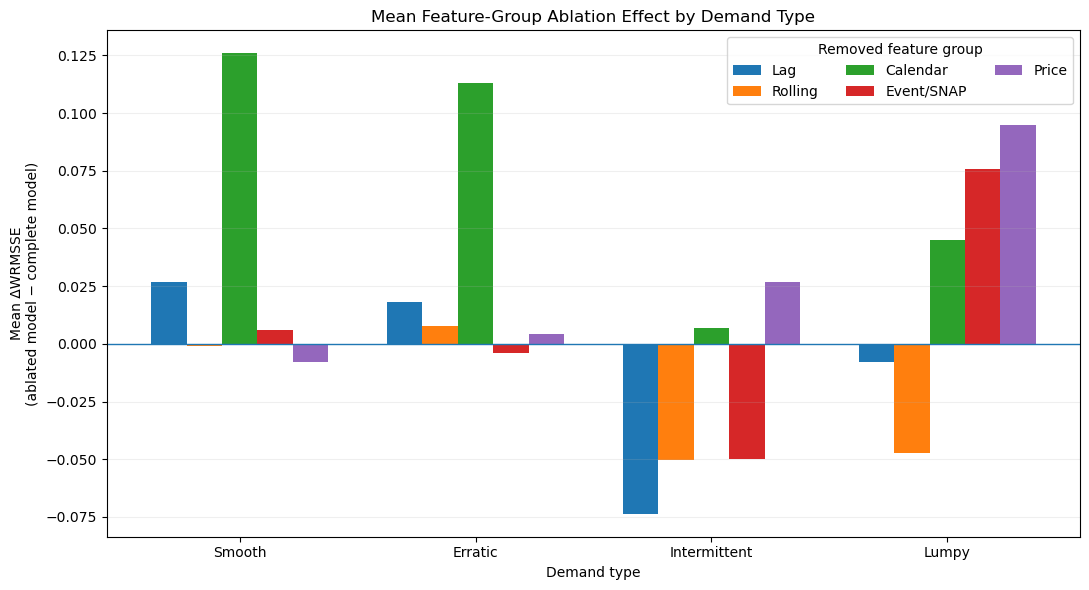

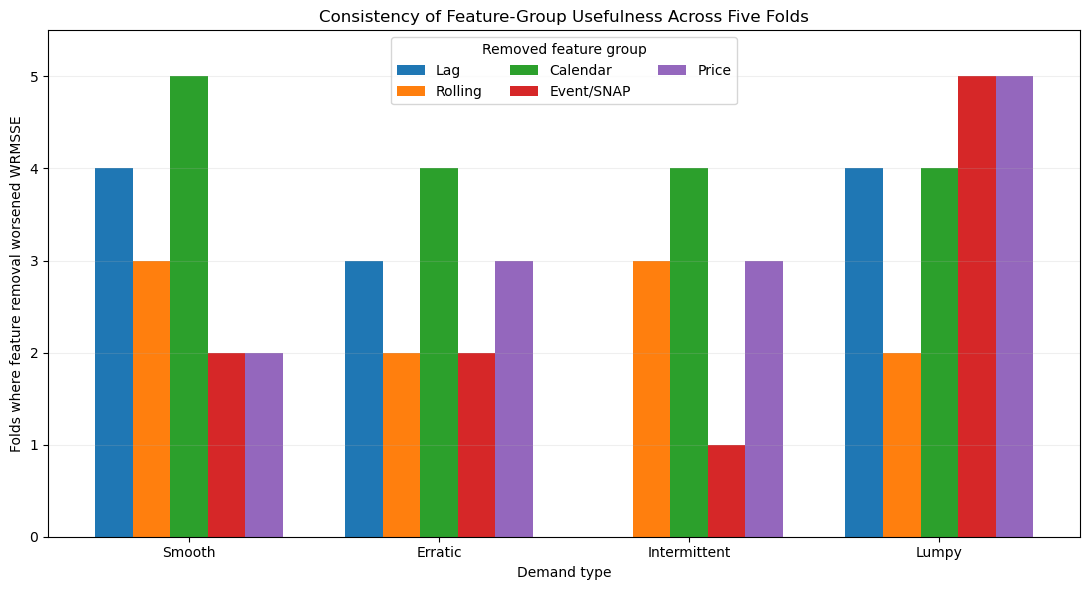

Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step17\step17_mean_delta_wrmsse_by_demand_type.png
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step17\step17_feature_usefulness_fold_counts.png


In [24]:
# Cell 23: Create Step 17 report figures

import matplotlib.pyplot as plt

FEATURE_GROUP_LABELS = {
    "lag": "Lag",
    "rolling": "Rolling",
    "calendar": "Calendar",
    "event_snap": "Event/SNAP",
    "price": "Price",
}

plot_feature_groups = list(
    FEATURE_GROUPS.keys()
)

plot_demand_types = DEMAND_TYPES

x_positions = np.arange(
    len(plot_demand_types)
)

bar_width = 0.15

fig, ax = plt.subplots(
    figsize=(11, 6)
)

for group_index, feature_group in enumerate(
    plot_feature_groups
):
    group_values = (
        step17_report_summary.loc[
            step17_report_summary[
                "removed_feature_group"
            ] == feature_group
        ]
        .set_index(DEMAND_TYPE_COLUMN)
        .reindex(plot_demand_types)[
            "mean_delta_wrmsse"
        ]
        .to_numpy()
    )

    offset = (
        group_index
        - (
            len(plot_feature_groups) - 1
        ) / 2
    ) * bar_width

    ax.bar(
        x_positions + offset,
        group_values,
        bar_width,
        label=(
            FEATURE_GROUP_LABELS[
                feature_group
            ]
        ),
    )

ax.axhline(
    0,
    linewidth=1,
)

ax.set_xlabel("Demand type")
ax.set_ylabel(
    "Mean ΔWRMSSE\n"
    "(ablated model − complete model)"
)

ax.set_title(
    "Mean Feature-Group Ablation Effect "
    "by Demand Type"
)

ax.set_xticks(
    x_positions,
    [
        demand_type.capitalize()
        for demand_type in plot_demand_types
    ],
)

ax.legend(
    title="Removed feature group",
    ncol=3,
)

ax.grid(
    axis="y",
    alpha=0.2,
)

fig.tight_layout()

mean_delta_figure = (
    STEP17_FIGURE_DIR
    / "step17_mean_delta_wrmsse_by_demand_type.png"
)

fig.savefig(
    mean_delta_figure,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


fig, ax = plt.subplots(
    figsize=(11, 6)
)

for group_index, feature_group in enumerate(
    plot_feature_groups
):
    group_values = (
        step17_report_summary.loc[
            step17_report_summary[
                "removed_feature_group"
            ] == feature_group
        ]
        .set_index(DEMAND_TYPE_COLUMN)
        .reindex(plot_demand_types)[
            "folds_removal_worsened_wrmsse"
        ]
        .to_numpy()
    )

    offset = (
        group_index
        - (
            len(plot_feature_groups) - 1
        ) / 2
    ) * bar_width

    ax.bar(
        x_positions + offset,
        group_values,
        bar_width,
        label=(
            FEATURE_GROUP_LABELS[
                feature_group
            ]
        ),
    )

ax.set_xlabel("Demand type")
ax.set_ylabel(
    "Folds where feature removal "
    "worsened WRMSSE"
)

ax.set_title(
    "Consistency of Feature-Group Usefulness "
    "Across Five Folds"
)

ax.set_xticks(
    x_positions,
    [
        demand_type.capitalize()
        for demand_type in plot_demand_types
    ],
)

ax.set_yticks(
    range(0, 6)
)

ax.set_ylim(
    0,
    5.5,
)

ax.legend(
    title="Removed feature group",
    ncol=3,
)

ax.grid(
    axis="y",
    alpha=0.2,
)

fig.tight_layout()

fold_consistency_figure = (
    STEP17_FIGURE_DIR
    / "step17_feature_usefulness_fold_counts.png"
)

fig.savefig(
    fold_consistency_figure,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(mean_delta_figure)
print(fold_consistency_figure)

### Mean Change in WRMSSE After Feature-Group Removal

The figure compares the average change in WRMSSE when each feature group was removed from the complete XGBoost model. Positive values mean that removal worsened performance, while negative values mean that the reduced model achieved a lower WRMSSE.
### Consistency of Feature-Group Usefulness Across the Five Folds

The figure shows the number of walk-forward folds in which removing each feature group increased WRMSSE. A value of five means that the feature group was useful in every fold for that demand type.

In [25]:
# Cell 24: Summarise ablation effects by hierarchy level

hierarchy_order = {
    level_name: index
    for index, (
        level_name,
        _
    ) in enumerate(HIERARCHY_LEVELS)
}

demand_order = {
    demand_type: index
    for index, demand_type
    in enumerate(DEMAND_TYPES)
}

feature_order = {
    feature_group: index
    for index, feature_group
    in enumerate(FEATURE_GROUPS)
}

step17_hierarchy_summary = (
    ablation_level_results
    .groupby(
        [
            DEMAND_TYPE_COLUMN,
            "removed_feature_group",
            "level",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        folds=("fold", "nunique"),
        mean_full_level_wrmsse=(
            "full_xgb_level_wrmsse",
            "mean",
        ),
        mean_ablation_level_wrmsse=(
            "ablation_level_wrmsse",
            "mean",
        ),
        mean_delta_level_wrmsse=(
            "delta_level_wrmsse",
            "mean",
        ),
        median_delta_level_wrmsse=(
            "delta_level_wrmsse",
            "median",
        ),
        folds_removal_worsened_level=(
            "feature_group_useful_at_level",
            "sum",
        ),
    )
)

step17_hierarchy_summary[
    "demand_order"
] = (
    step17_hierarchy_summary[
        DEMAND_TYPE_COLUMN
    ].map(demand_order)
)

step17_hierarchy_summary[
    "feature_order"
] = (
    step17_hierarchy_summary[
        "removed_feature_group"
    ].map(feature_order)
)

step17_hierarchy_summary[
    "hierarchy_order"
] = (
    step17_hierarchy_summary[
        "level"
    ].map(hierarchy_order)
)

step17_hierarchy_summary = (
    step17_hierarchy_summary
    .sort_values(
        [
            "demand_order",
            "feature_order",
            "hierarchy_order",
        ]
    )
    .drop(
        columns=[
            "demand_order",
            "feature_order",
            "hierarchy_order",
        ]
    )
    .reset_index(drop=True)
)

assert len(step17_hierarchy_summary) == 240
assert (
    step17_hierarchy_summary["folds"]
    == 5
).all()

display(
    step17_hierarchy_summary.round(6)
)

step17_hierarchy_summary.to_csv(
    STEP17_TABLE_DIR
    / "step17_hierarchy_ablation_summary.csv",
    index=False,
)

print("Hierarchy-level ablation summary saved.")

,demand_type,removed_feature_group,level,folds,mean_full_level_wrmsse,mean_ablation_level_wrmsse,mean_delta_level_wrmsse,median_delta_level_wrmsse,folds_removal_worsened_level
0,smooth,lag,L1_Total,5,0.483884,0.538773,0.054889,0.074046,4
1,smooth,lag,L2_State,5,0.539925,0.581696,0.041771,0.056386,3
2,smooth,lag,L3_Store,5,0.632208,0.660369,0.028161,0.041072,3
3,smooth,lag,L4_Category,5,0.551714,0.593056,0.041343,0.059545,4
4,smooth,lag,L5_Department,5,0.575191,0.611806,0.036615,0.047730,4
...,...,...,...,...,...,...,...,...,...
235,lumpy,price,L8_Store_Category,5,1.108921,1.179390,0.070469,0.064603,5
236,lumpy,price,L9_Store_Department,5,1.128941,1.199198,0.070258,0.058329,5
237,lumpy,price,L10_Item,5,1.074111,1.126208,0.052098,0.048184,5
238,lumpy,price,L11_Item_State,5,1.065788,1.117273,0.051486,0.047543,5


Hierarchy-level ablation summary saved.


In [26]:
# Cell 25: Final Step 17 completion audit

step17_configuration = {
    "seed": SEED,
    "xgboost_version": xgb.__version__,
    "objective": XGB_PARAMS["objective"],
    "tweedie_variance_power": (
        XGB_PARAMS[
            "tweedie_variance_power"
        ]
    ),
    "feature_groups": FEATURE_GROUPS,
    "ablation_design": (
        "leave-one-feature-group-out"
    ),
    "retune_ablated_models": False,
    "rounds_source": (
        "Step 16 fold-and-demand-type-specific "
        "selected rounds"
    ),
    "primary_metric": "WRMSSE",
    "secondary_metrics": [
        "MAE",
        "RMSE",
    ],
    "folds": 5,
    "demand_types": DEMAND_TYPES,
    "ablation_models": 100,
    "recursive_forecasting": True,
}

STEP17_CONFIGURATION_FILE = (
    STEP17_TABLE_DIR
    / "step17_configuration.json"
)

with open(
    STEP17_CONFIGURATION_FILE,
    "w",
    encoding="utf-8",
) as configuration_file:
    json.dump(
        step17_configuration,
        configuration_file,
        indent=2,
    )

saved_experiment_prediction_files = list(
    STEP17_RESULT_DIR.glob(
        "step17_predictions_*.parquet"
    )
)

required_step17_outputs = [
    STEP17_TABLE_DIR
    / "step17_ablation_plan.csv",

    STEP17_TABLE_DIR
    / "step17_ablation_results.csv",

    STEP17_TABLE_DIR
    / "step17_ablation_level_results.csv",

    STEP17_TABLE_DIR
    / "step17_ablation_summary_by_demand_type.csv",

    STEP17_TABLE_DIR
    / "step17_report_summary.csv",

    STEP17_TABLE_DIR
    / "step17_feature_group_ranking.csv",

    STEP17_TABLE_DIR
    / "step17_hierarchy_ablation_summary.csv",

    STEP17_CONFIGURATION_FILE,

    MODEL_RESULTS_DIR
    / "step17_ablation_predictions.parquet",

    STEP17_FIGURE_DIR
    / "step17_mean_delta_wrmsse_by_demand_type.png",

    STEP17_FIGURE_DIR
    / "step17_feature_usefulness_fold_counts.png",
]

missing_step17_outputs = [
    path
    for path in required_step17_outputs
    if not path.exists()
]

step17_completion_checks = {
    "100 ablation models completed": (
        len(ablation_results) == 100
    ),
    "560,000 ablation predictions": (
        len(ablation_predictions)
        == 560_000
    ),
    "1,200 hierarchy-level results": (
        len(ablation_level_results)
        == 1_200
    ),
    "20 demand-feature summary rows": (
        len(step17_report_summary) == 20
    ),
    "240 hierarchy summary rows": (
        len(step17_hierarchy_summary)
        == 240
    ),
    "100 individual prediction files": (
        len(
            saved_experiment_prediction_files
        ) == 100
    ),
    "No required output missing": (
        len(missing_step17_outputs) == 0
    ),
    "No missing forecasts": (
        ablation_predictions[
            "ablation_forecast"
        ].isna().sum() == 0
    ),
    "No non-finite forecasts": (
        np.isfinite(
            ablation_predictions[
                "ablation_forecast"
            ].to_numpy()
        ).all()
    ),
    "No negative forecasts": (
        (
            ablation_predictions[
                "ablation_forecast"
            ] < 0
        ).sum() == 0
    ),
    "Five removals per fold and demand type": (
        ablation_results
        .groupby(
            [
                "fold",
                DEMAND_TYPE_COLUMN,
            ],
            observed=True,
        )["removed_feature_group"]
        .nunique()
        .eq(5)
        .all()
    ),
}

step17_completion_table = pd.DataFrame(
    {
        "check": (
            step17_completion_checks.keys()
        ),
        "passed": (
            step17_completion_checks.values()
        ),
    }
)

display(step17_completion_table)

if missing_step17_outputs:
    print("Missing outputs:")

    for missing_path in (
        missing_step17_outputs
    ):
        print(missing_path)

failed_step17_checks = [
    check
    for check, passed
    in step17_completion_checks.items()
    if not passed
]

if failed_step17_checks:
    raise AssertionError(
        "Step 17 completion audit failed:\n- "
        + "\n- ".join(
            failed_step17_checks
        )
    )

step17_completion_table.to_csv(
    STEP17_TABLE_DIR
    / "step17_completion_audit.csv",
    index=False,
)

print("Step 17 completion audit passed.")
print(
    f"Required output files checked: "
    f"{len(required_step17_outputs)}"
)
print(
    f"Individual prediction files: "
    f"{len(saved_experiment_prediction_files)}"
)

,check,passed
0,100 ablation models completed,True
1,"560,000 ablation predictions",True
2,"1,200 hierarchy-level results",True
3,20 demand-feature summary rows,True
4,240 hierarchy summary rows,True
5,100 individual prediction files,True
6,No required output missing,True
7,No missing forecasts,True
8,No non-finite forecasts,True
9,No negative forecasts,True


Step 17 completion audit passed.
Required output files checked: 11
Individual prediction files: 100


## Step 17 Interpretation Log

| ID | Verified finding | Interpretation | Important limitation |
|---|---|---|---|
| I17.1 | Removing calendar features increased smooth-demand WRMSSE by an average of 0.125891. Performance deteriorated in all five folds and at an average of all 12 hierarchy levels. | Calendar information was the most consistently useful feature group for smooth demand. | The ablated model was not separately retuned, so the result measures removal under the complete model’s selected round count. |
| I17.2 | Removing calendar features increased erratic-demand WRMSSE by an average of 0.113205 and worsened four of five folds. | Calendar features were also the strongest feature group for erratic demand. | Fold 1 changed by only −0.000036, showing that the contribution was not equally strong in every period. |
| I17.3 | Removing lag features reduced intermittent-demand WRMSSE in all five folds, with a mean ΔWRMSSE of −0.073589. | Under the fixed ablation configuration, lag features did not improve intermittent-demand WRMSSE and their removal consistently produced a lower score. | This does not prove that all lag information is intrinsically harmful. The result is conditional on the remaining features, selected lags and fixed boosting rounds. |
| I17.4 | Removing event/SNAP features improved intermittent-demand WRMSSE in four of five folds, with a mean ΔWRMSSE of −0.050043. | Event and SNAP features were not consistently beneficial for intermittent demand in the complete model. | Event-type effects may vary across dates, and this grouped ablation does not separate event indicators from SNAP. |
| I17.5 | Removing price features increased lumpy-demand WRMSSE by an average of 0.094992 and worsened all five folds. | Price features were the strongest and most consistent feature group for lumpy demand. | Missing price values were retained, and the result includes both price information and patterns associated with product availability. |
| I17.6 | Removing event/SNAP features increased lumpy-demand WRMSSE by an average of 0.075897 and worsened all five folds. | Event and SNAP information provided a consistent contribution for lumpy demand. | The result does not identify whether event indicators, event type or SNAP produced the contribution individually. |
| I17.7 | Lumpy lag removal worsened four of five folds but produced a negative mean ΔWRMSSE of −0.007926 because Fold 1 improved substantially when lags were removed. | The lag contribution for lumpy demand was temporally unstable, and the mean alone gives a different impression from the fold count. | Both the mean effect and the number of folds must be reported. |
| I17.8 | No feature group had the same pattern across all four demand types. | Feature usefulness depended on demand type, supporting demand-type-specific model analysis rather than a universal feature ranking. | Leave-one-group-out ablation measures marginal contribution conditional on all retained groups and does not establish causality. |

## Step 17 Surprise Log

| ID | Expected result | Surprising result | Why it matters | Follow-up |
|---|---|---|---|---|
| S17.1 | Lag features were expected to improve smooth-demand forecasting in the Fold 1 pilot. | Removing all four lag features improved Fold 1 smooth WRMSSE by 4.8606%. | Recent lag information was not automatically beneficial in every forecast period, even for smooth demand. | Compare lag SHAP values and feature interactions across smooth-demand folds. |
| S17.2 | Lag features were expected to be particularly important for intermittent demand because recent non-zero observations may contain timing information. | Removing lag features improved intermittent WRMSSE in all five folds, with a mean ΔWRMSSE of −0.073589. | The lag group showed the opposite pattern from the original expectation. | Examine individual lag features during SHAP analysis and retain the result without retuning on outer-test data. |
| S17.3 | Calendar features were expected to help intermittent demand consistently. | Calendar removal worsened four folds but improved Fold 1 by 0.396966 WRMSSE. | One forecast period was large enough to make the mean calendar contribution appear much smaller than the fold consistency suggested. | Report the Fold 1 exception and inspect its calendar and event period during later analysis. |
| S17.4 | A feature group that helped most folds was expected to have a positive mean ΔWRMSSE. | Lumpy lag removal worsened four folds but produced a negative mean ΔWRMSSE because Fold 1 improved by 0.199556. | Mean effects and fold frequencies can produce conflicting conclusions when one fold is unusually large. | Report both summaries and avoid ranking lumpy lag features using the mean alone. |
| S17.5 | Event/SNAP features were expected to have a broadly similar effect across sparse demand types. | Removing event/SNAP improved intermittent demand in four folds but worsened lumpy demand in all five folds. | The same feature group had opposite patterns for intermittent and lumpy demand. | Use SHAP to examine event and SNAP contributions separately by demand type. |
| S17.6 | Rolling features were expected to provide stable information by smoothing daily demand variation. | Rolling-feature removal improved mean WRMSSE for smooth, intermittent and lumpy demand, although the fold directions were mixed. | Rolling statistics may duplicate information already represented by lag features or may smooth away useful sparse-demand changes. | Examine dependence and correlation between lag and rolling features before drawing a final conclusion. |
| S17.7 | Improvements in WRMSSE, MAE and RMSE were expected to move in the same direction. | Some ablations improved WRMSSE while worsening MAE or RMSE, including smooth-demand lag removal in the pilot. | A feature group may affect bottom-level and hierarchical errors differently. | Keep WRMSSE as the primary decision metric and report secondary-metric disagreements where relevant. |